# DIABETES PREDICTION - DEEP LEARNING FROM SCRATCH (NUMPY ONLY)

Pipeline: **Raw Data → Understand → Clean → Represent → Learn → Evaluate**

Notebook này gồm:
- Khám phá và làm sạch dataset Diabetes.
- Xử lý missing values và ký hiệu `?`.
- One-hot encoding và chuẩn hóa dữ liệu.
- Xây dựng baseline bằng Logistic Regression, Random Forest và XGBoost/Gradient Boosting.
- Xây dựng MLP **5 lớp** từ đầu bằng **NumPy**, không dùng PyTorch/Keras/TensorFlow cho phần Deep Learning.
- Mini-batch training với SGD/Adam.
- Thử nghiệm learning rate, batch size, architecture và optimizer.
- Đánh giá bằng Accuracy, Precision, Recall, F1 và ROC-AUC.
- Permutation feature importance và threshold tuning.

In [1]:
# ============================================================
# CELL 1: IMPORT & SETUP
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# For ML baseline comparison
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve,
    classification_report
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not available, will use GradientBoosting instead")
    from sklearn.ensemble import GradientBoostingClassifier

np.random.seed(42)
print("Setup complete.")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

XGBoost not available, will use GradientBoosting instead
Setup complete.
NumPy version: 2.5.2
Pandas version: 3.0.5


In [2]:
# ============================================================
# CELL 2: LOAD DATA & INITIAL UNDERSTANDING
# ============================================================

DATA_PATH = "data/final_messy_diabetes_dataset.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

print("\n=== First 5 rows ===")
display(df.head())

print("\n=== Column dtypes ===")
print(df.dtypes)

print("\n=== Target distribution ===")
print(df['diagnosed_diabetes'].value_counts())

print(f"Positive rate: {df['diagnosed_diabetes'].mean():.4f}")

Dataset shape: (100000, 34)
Number of rows: 100,000
Number of columns: 34

=== First 5 rows ===


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes,patient_tracking_id,data_entry_notes,experimental_peptide_level
0,58.0,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,136,236,6.36,8.18,29.6,Type 2,1,NaN,IGNORE,NaN
1,48.0,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,93,150,2.00,5.63,23.0,No Diabetes,0,NaN,IGNORE,NaN
2,60.0,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,118,195,5.07,7.51,44.7,Type 2,1,NaN,IGNORE,NaN
3,74.0,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,139,253,5.28,9.03,38.2,Type 2,1,NaN,IGNORE,NaN
4,46.0,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,137,184,12.74,7.20,23.5,Type 2,1,NaN,IGNORE,NaN



=== Column dtypes ===
age                                   float64
gender                                    str
ethnicity                                 str
education_level                           str
income_level                              str
employment_status                         str
smoking_status                            str
alcohol_consumption_per_week            int64
physical_activity_minutes_per_week      int64
diet_score                            float64
sleep_hours_per_day                   float64
screen_time_hours_per_day             float64
family_history_diabetes                 int64
hypertension_history                    int64
cardiovascular_history                  int64
bmi                                   float64
waist_to_hip_ratio                    float64
systolic_bp                             int64
diastolic_bp                            int64
heart_rate                              int64
cholesterol_total                         str
hdl_cholest

=== '?' counts per object column ===

=== Missing values (top) ===
                            Missing  Percent
patient_tracking_id           95000     95.0
experimental_peptide_level    50000     50.0
data_entry_notes              10000     10.0
age                            5000      5.0
bmi                            5000      5.0


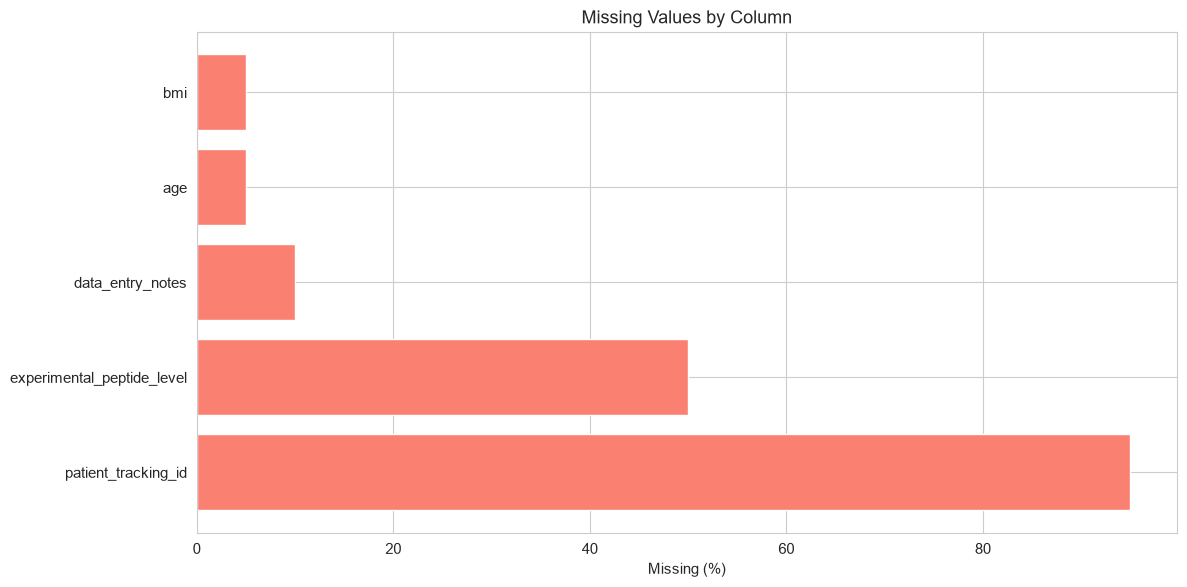

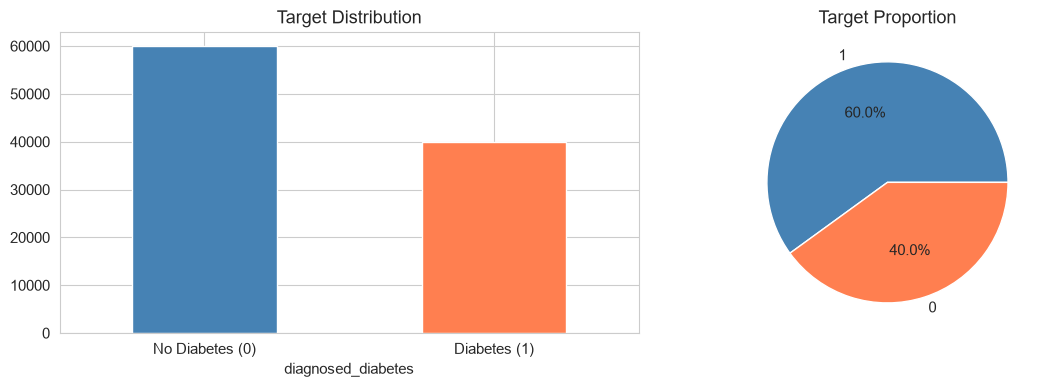

In [3]:
# ============================================================
# CELL 3: DATA QUALITY - MISSING VALUES & '?' MARKERS
# ============================================================

# Count '?' in object columns
print("=== '?' counts per object column ===")
for col in df.columns:
    if df[col].dtype == 'object':
        n_q = (df[col] == '?').sum()
        if n_q > 0:
            print(f"  {col}: {n_q}")

# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

miss_df = pd.DataFrame({
    'Missing': missing,
    'Percent': missing_pct
}).sort_values('Missing', ascending=False)

print("\n=== Missing values (top) ===")
print(miss_df[miss_df['Missing'] > 0].head(20))

# Visualize missing
fig, ax = plt.subplots(figsize=(12, 6))
miss_plot = miss_df[miss_df['Missing'] > 0]

if len(miss_plot) > 0:
    ax.barh(miss_plot.index, miss_plot['Percent'], color='salmon')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values by Column')
    plt.tight_layout()
    plt.show()

# Target distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['diagnosed_diabetes'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=['steelblue', 'coral']
)
axes[0].set_title('Target Distribution')
axes[0].set_xticklabels(
    ['No Diabetes (0)', 'Diabetes (1)'],
    rotation=0
)

df['diagnosed_diabetes'].value_counts().plot(
    kind='pie',
    ax=axes[1],
    autopct='%1.1f%%',
    colors=['steelblue', 'coral']
)
axes[1].set_title('Target Proportion')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# 4. DATA CLEANING
# ============================================================
df_clean = df.copy()

# 3.1 Replace '?' with NaN
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].replace('?', np.nan)

# 3.2 Drop ID and text columns (kể cả các biến thể tên)
DROP_COLS = ['patient_tracking_id', 'data_entry_notes']
existing_drop = [c for c in DROP_COLS if c in df_clean.columns]
df_clean = df_clean.drop(columns=existing_drop)
print(f"Dropped columns: {existing_drop}")

# 3.3 DROP target leakage column: diabetes_stage
if 'diabetes_stage' in df_clean.columns:
    print("\n=== diabetes_stage vs target ===")
    print(pd.crosstab(df_clean['diabetes_stage'], df_clean['diagnosed_diabetes']))
    df_clean = df_clean.drop(columns=['diabetes_stage'])
    print("Dropped 'diabetes_stage' (target leakage)")

# 3.4 Convert numeric columns
numeric_cols = []
for col in df_clean.columns:
    if col == 'diagnosed_diabetes':
        continue
    converted = pd.to_numeric(df_clean[col], errors='coerce')
    if converted.notna().mean() > 0.5:
        df_clean[col] = converted
        numeric_cols.append(col)

print(f"\nNumeric columns ({len(numeric_cols)}):")
print(numeric_cols)

# 3.5 Categorical columns — CHỈ giữ những cột object còn lại
cat_cols = [c for c in df_clean.columns
            if c not in numeric_cols and c != 'diagnosed_diabetes']

# ⚠️ IN RA CARDINALITY ĐỂ PHÁT HIỆN CỘT NGUY HIỂM
print("\n=== Categorical column cardinality ===")
card_info = []
for col in cat_cols:
    n_unique = df_clean[col].nunique(dropna=True)
    card_info.append({'Column': col, 'Unique': n_unique, 'Dtype': str(df_clean[col].dtype)})
card_df = pd.DataFrame(card_info).sort_values('Unique', ascending=False)
print(card_df.to_string(index=False))

# ⚠️ LOẠI BỎ các cột có cardinality quá cao (>50) — đây là thủ phạm gây MemoryError
HIGH_CARD_THRESHOLD = 50
high_card_cols = [c for c in cat_cols if df_clean[c].nunique(dropna=True) > HIGH_CARD_THRESHOLD]
print(f"\n⚠️ High-cardinality columns (>{HIGH_CARD_THRESHOLD} unique) sẽ bị DROP:")
print(high_card_cols)

df_clean = df_clean.drop(columns=high_card_cols)
cat_cols = [c for c in cat_cols if c not in high_card_cols]

# Kiểm tra lại
print(f"\nRemaining categorical columns ({len(cat_cols)}):")
for c in cat_cols:
    print(f"  {c}: {df_clean[c].nunique(dropna=True)} unique")

print(f"\nAfter cleaning shape: {df_clean.shape}")

Dropped columns: ['patient_tracking_id', 'data_entry_notes']

=== diabetes_stage vs target ===
diagnosed_diabetes      0      1
diabetes_stage                  
Gestational           120    158
No Diabetes          7981      0
Pre-Diabetes        31845      0
Type 1                 56     66
Type 2                  0  59774
Dropped 'diabetes_stage' (target leakage)

Numeric columns (23):
['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score']

=== Categorical column cardinality ===
                    Column  Unique   Dtype
experimental_peptide_level   50000 float64
              income

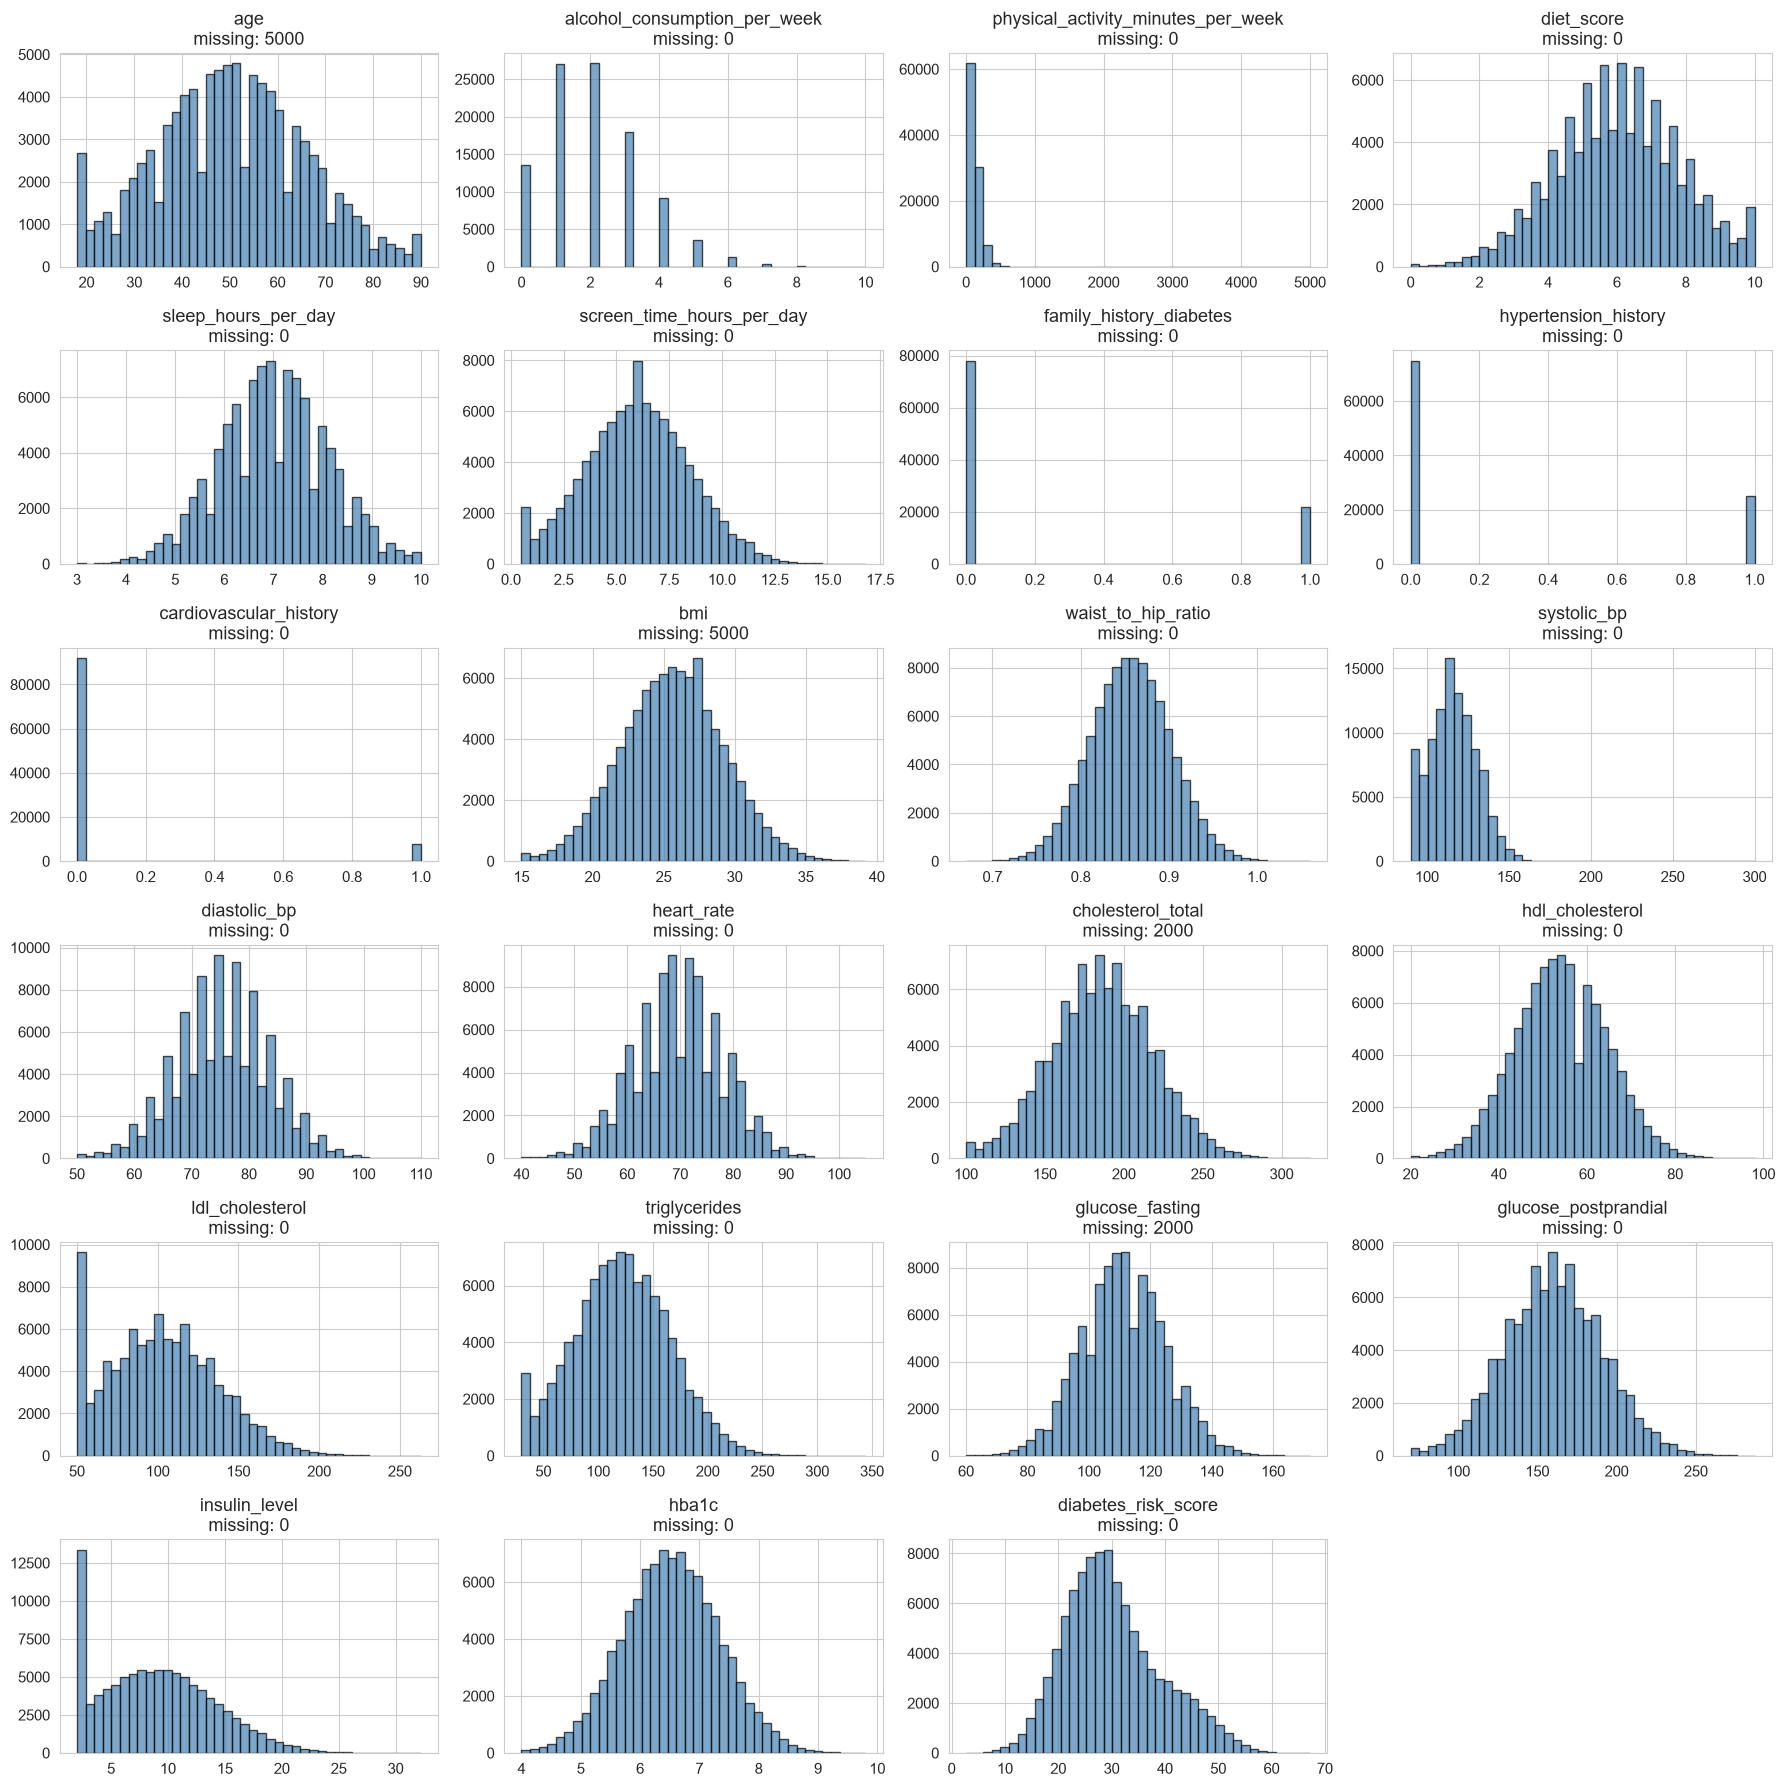

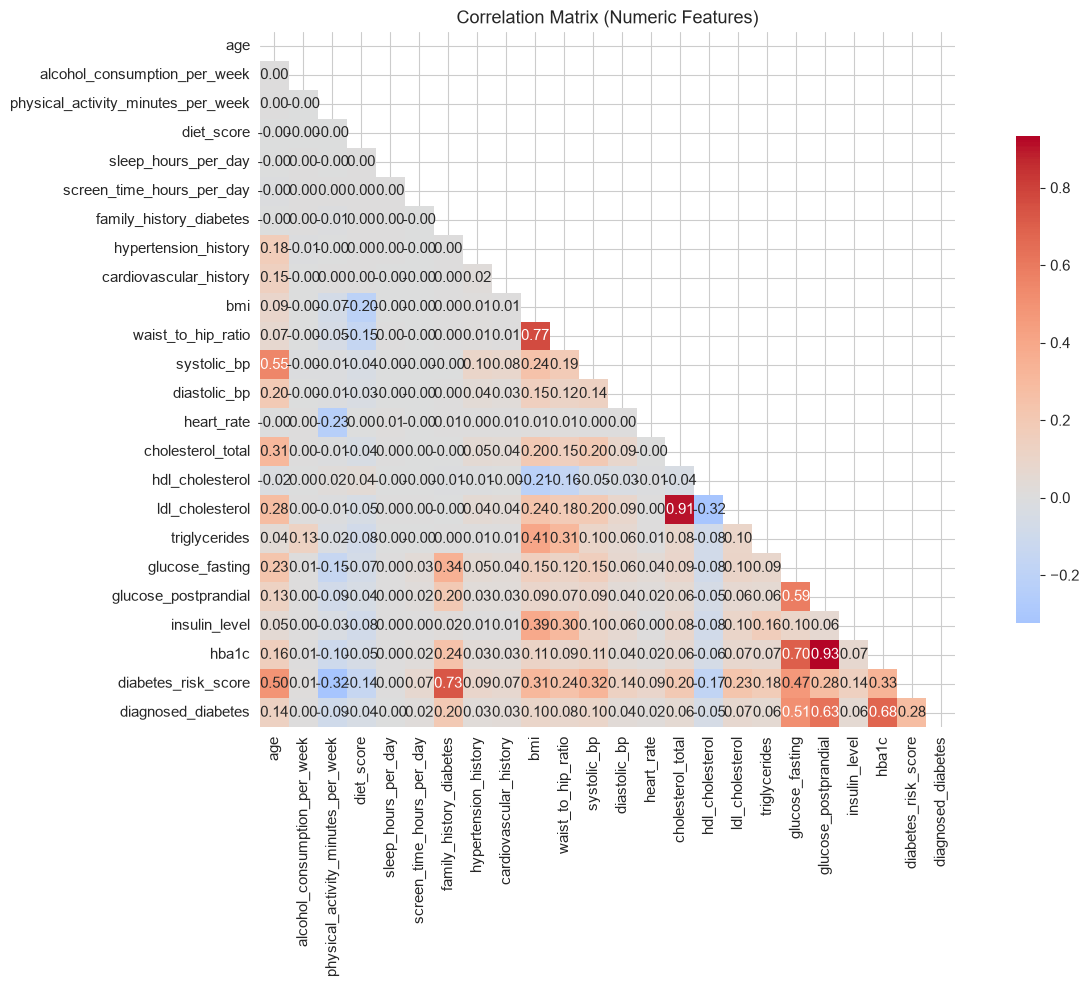

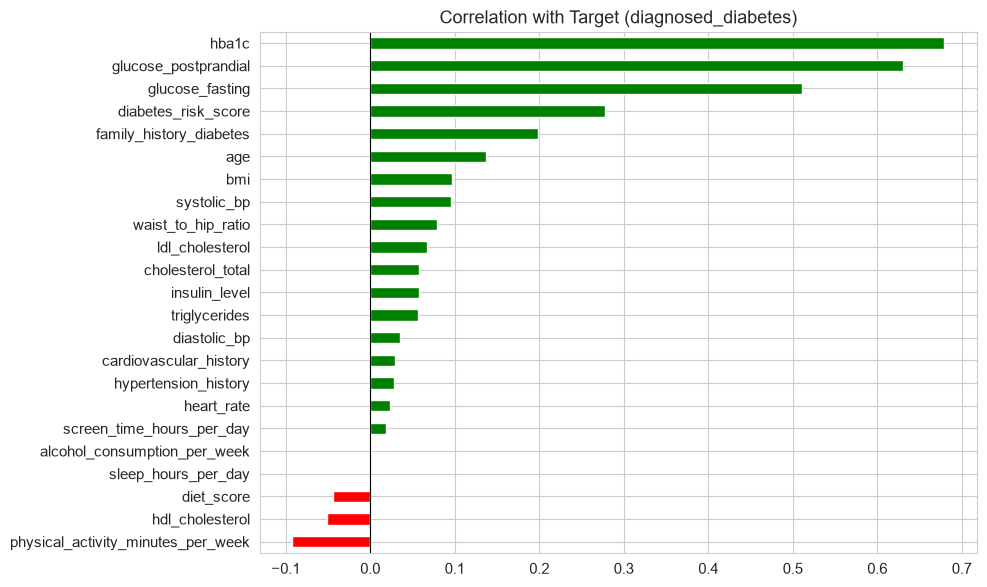

In [5]:
# ============================================================
# CELL 5: EDA - NUMERICAL & CATEGORICAL
# ============================================================

# 5.1 Numeric distributions
n_num = len(numeric_cols)
n_cols_plot = 4
n_rows_plot = (n_num + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(
    n_rows_plot,
    n_cols_plot,
    figsize=(18, 3 * n_rows_plot)
)

axes = np.atleast_1d(axes).flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(
        df_clean[col].dropna(),
        bins=40,
        color='steelblue',
        edgecolor='black',
        alpha=0.7
    )
    axes[i].set_title(
        f'{col}\nmissing: {df_clean[col].isnull().sum()}'
    )
    axes[i].set_xlabel('')

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# 5.2 Correlation heatmap
plt.figure(figsize=(14, 10))

corr_cols = numeric_cols + ['diagnosed_diabetes']
corr = df_clean[corr_cols].corr()

mask = np.triu(
    np.ones_like(corr, dtype=bool)
)

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    cbar_kws={'shrink': 0.7}
)

plt.title('Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.show()

# 5.3 Target correlation
target_corr = (
    corr['diagnosed_diabetes']
    .drop('diagnosed_diabetes')
    .sort_values()
)

plt.figure(figsize=(10, 6))

colors = [
    'red' if x < 0 else 'green'
    for x in target_corr.values
]

target_corr.plot(
    kind='barh',
    color=colors
)

plt.title(
    'Correlation with Target (diagnosed_diabetes)'
)
plt.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()


=== gender ===
gender
Female    50216
Male      47771
Other      2013
Name: count, dtype: int64

=== ethnicity ===
ethnicity
White       44997
Hispanic    20103
Black       17986
Asian       11865
Other        5049
Name: count, dtype: int64

=== education_level ===
education_level
Highschool      44891
Graduate        35037
Postgraduate    14972
No formal        5100
Name: count, dtype: int64

=== income_level ===
income_level
Middle          35152
Lower-Middle    25150
Upper-Middle    19866
Low             14830
High             5002
Name: count, dtype: int64

=== employment_status ===
employment_status
Employed      60175
Retired       21761
Unemployed    11918
Student        6146
Name: count, dtype: int64

=== smoking_status ===
smoking_status
Never      59813
Current    20176
Former     20011
Name: count, dtype: int64


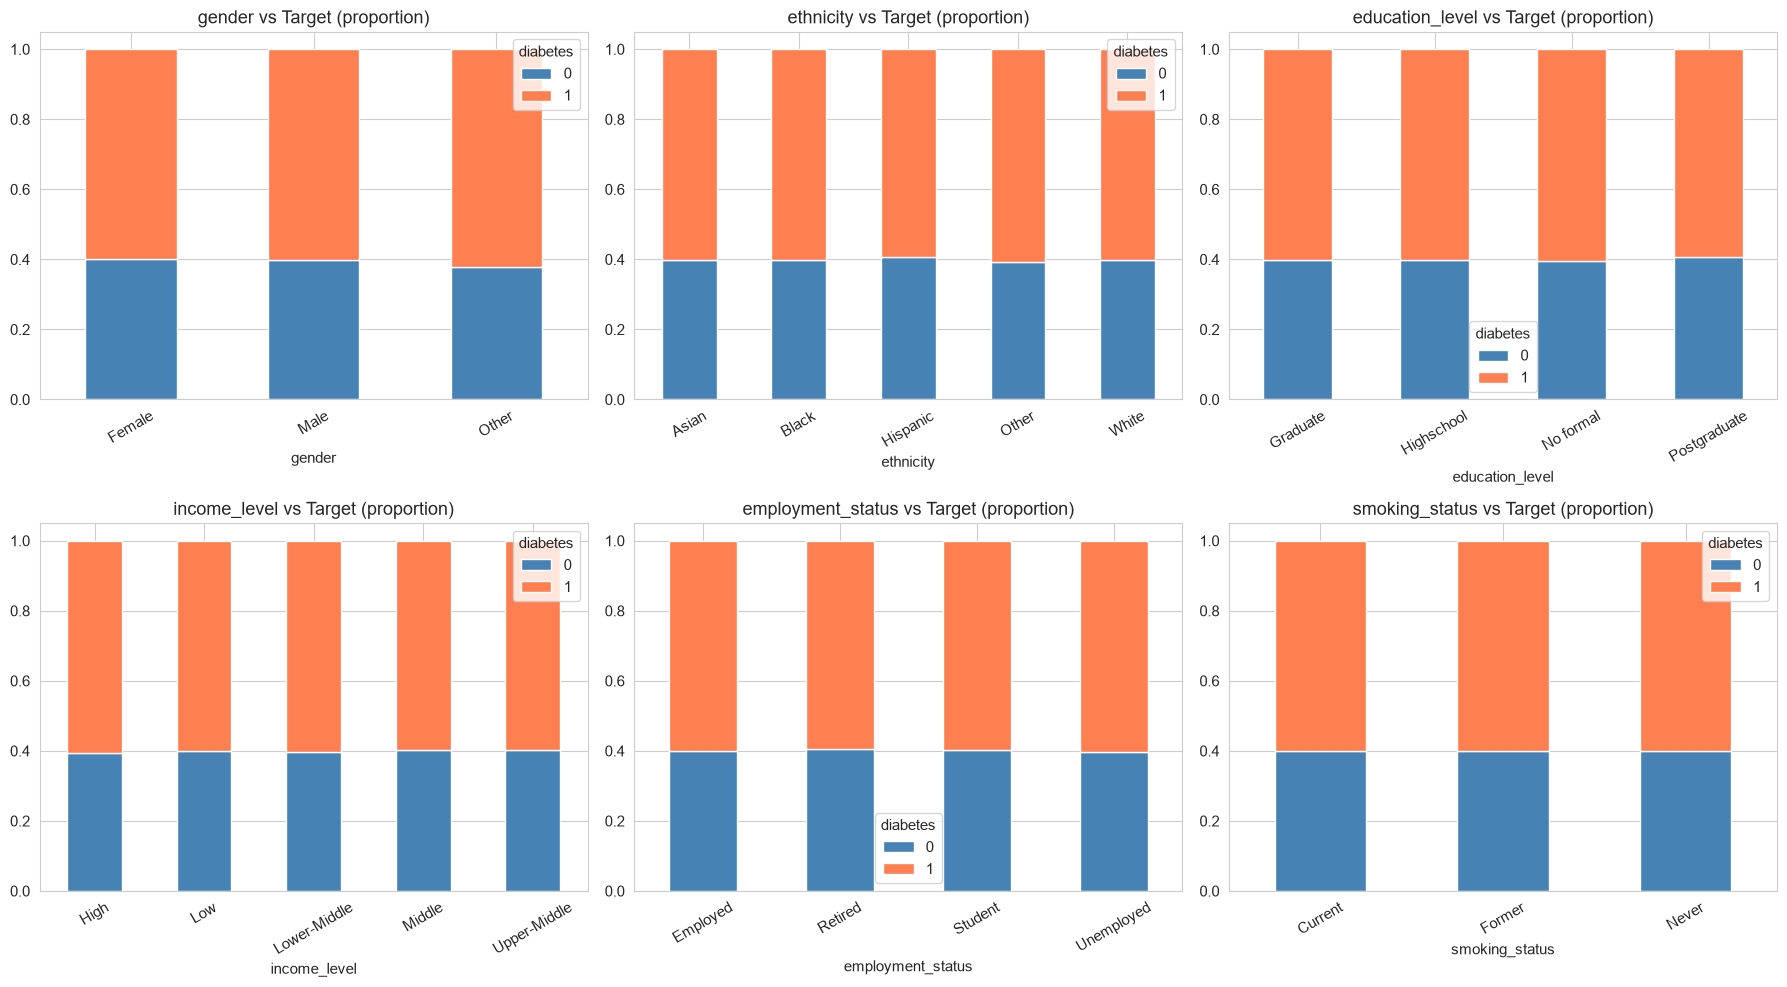

In [6]:
# ============================================================
# CELL 6: CATEGORICAL ANALYSIS & HANDLING
# ============================================================

for col in cat_cols:
    print(f"\n=== {col} ===")
    print(
        df_clean[col]
        .value_counts(dropna=False)
        .head(10)
    )

# Visualize categorical vs target
if len(cat_cols) > 0:
    n_show = min(6, len(cat_cols))
    n_cat_cols = 3
    n_cat_rows = (n_show + n_cat_cols - 1) // n_cat_cols

    fig, axes = plt.subplots(
        n_cat_rows,
        n_cat_cols,
        figsize=(18, 5 * n_cat_rows)
    )

    axes = np.atleast_1d(axes).flatten()

    for i, col in enumerate(cat_cols[:n_show]):
        ct = pd.crosstab(
            df_clean[col],
            df_clean['diagnosed_diabetes'],
            normalize='index'
        )

        ct.plot(
            kind='bar',
            ax=axes[i],
            stacked=True,
            color=['steelblue', 'coral']
        )

        axes[i].set_title(
            f'{col} vs Target (proportion)'
        )
        axes[i].legend(
            title='diabetes',
            loc='best'
        )
        axes[i].tick_params(
            axis='x',
            rotation=30
        )

    for j in range(n_show, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns found.")

In [7]:
# ============================================================
# 7. IMPUTATION & ENCODING
# ============================================================
df_proc = df_clean.copy()

# 6.1 Separate features and target
y_all = df_proc['diagnosed_diabetes'].values.astype(np.float32)
X_df = df_proc.drop(columns=['diagnosed_diabetes'])

# 6.2 Fill categorical NaN with mode
for col in cat_cols:
    if X_df[col].isnull().any():
        mode_val = X_df[col].mode()[0]
        X_df[col] = X_df[col].fillna(mode_val)

# 6.3 Sanity check TRƯỚC khi one-hot
print("=== Sanity check before one-hot ===")
total_dummies = 0
for col in cat_cols:
    n = X_df[col].nunique(dropna=True)
    total_dummies += n
    print(f"  {col}: {n} unique -> {n} dummies")
print(f"Total dummy columns expected: {total_dummies}")
print(f"Estimated memory for one-hot: {len(X_df) * (len(numeric_cols) + total_dummies) * 4 / 1e9:.2f} GB")

# ⚠️ Nếu vẫn > 2 GB, cân nhắc dừng lại
MAX_MEM_GB = 4.0
est_mem = len(X_df) * (len(numeric_cols) + total_dummies) * 4 / 1e9
if est_mem > MAX_MEM_GB:
    raise MemoryError(f"Estimated memory {est_mem:.2f} GB > {MAX_MEM_GB} GB. Cần giảm cardinality!")

# 6.4 One-hot encode (dùng sparse=False nhưng cardinality đã được kiểm soát)
X_encoded = pd.get_dummies(
    X_df,
    columns=cat_cols,
    drop_first=False,
    dtype=np.float32
)
print(f"\nShape after one-hot: {X_encoded.shape}")
print(f"Actual memory: {X_encoded.memory_usage(deep=True).sum() / 1e9:.3f} GB")

# 6.5 Numeric missing
num_missing = X_encoded[numeric_cols].isnull().sum()
print("\nNumeric missing before imputation:")
print(num_missing[num_missing > 0])

feature_names = list(X_encoded.columns)
print(f"\nTotal features: {len(feature_names)}")

=== Sanity check before one-hot ===
  gender: 3 unique -> 3 dummies
  ethnicity: 5 unique -> 5 dummies
  education_level: 4 unique -> 4 dummies
  income_level: 5 unique -> 5 dummies
  employment_status: 4 unique -> 4 dummies
  smoking_status: 3 unique -> 3 dummies
Total dummy columns expected: 24
Estimated memory for one-hot: 0.02 GB

Shape after one-hot: (100000, 47)
Actual memory: 0.028 GB

Numeric missing before imputation:
age                  5000
bmi                  5000
cholesterol_total    2000
glucose_fasting      2000
dtype: int64

Total features: 47


In [8]:
# ============================================================
# CELL 8: TRAIN / VALIDATION / TEST SPLIT + NORMALIZATION
# ============================================================

# Split: 70% train, 15% validation, 15% test
X_np = X_encoded.values.astype(np.float32)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_np,
    y_all,
    test_size=0.15,
    random_state=42,
    stratify=y_all
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.15 / 0.85,
    random_state=42,
    stratify=y_train_full
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train pos rate: {y_train.mean():.4f}")
print(f"Val pos rate:   {y_val.mean():.4f}")
print(f"Test pos rate:  {y_test.mean():.4f}")

# ------------------------------------------------------------
# Imputation using TRAIN statistics only
# ------------------------------------------------------------
train_medians = np.nanmedian(X_train, axis=0)

def impute_with_train_median(X, medians):
    X = X.copy()

    inds = np.where(np.isnan(X))

    X[inds] = np.take(
        medians,
        inds[1]
    )

    return X

X_train = impute_with_train_median(
    X_train,
    train_medians
)

X_val = impute_with_train_median(
    X_val,
    train_medians
)

X_test = impute_with_train_median(
    X_test,
    train_medians
)

# ------------------------------------------------------------
# Standardization using TRAIN statistics only
# ------------------------------------------------------------
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0) + 1e-8

X_train = (X_train - mu) / sigma
X_val = (X_val - mu) / sigma
X_test = (X_test - mu) / sigma

# Reshape targets
y_train = y_train.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print("\nAfter imputation & normalization:")
print(
    f"X_train: {X_train.shape} "
    f"mean≈{X_train.mean():.4f} "
    f"std≈{X_train.std():.4f}"
)
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

print(
    f"No NaN: "
    f"{np.isnan(X_train).sum()}, "
    f"{np.isnan(X_val).sum()}, "
    f"{np.isnan(X_test).sum()}"
)

Train: (69999, 47), Val: (15001, 47), Test: (15000, 47)
Train pos rate: 0.6000
Val pos rate:   0.6000
Test pos rate:  0.6000

After imputation & normalization:
X_train: (69999, 47) mean≈0.0000 std≈1.0000
X_val:   (15001, 47)
X_test:  (15000, 47)
No NaN: 0, 0, 0


In [9]:
# ============================================================
# CELL 9: BASELINE MACHINE LEARNING MODELS
# ============================================================

def evaluate_model(name, y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )
    rec = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )
    auc = (
        roc_auc_score(y_true, y_prob)
        if y_prob is not None
        else np.nan
    )

    return {
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC-AUC': auc
    }

ml_results = []
ml_probs = {}

# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------
print("Training Logistic Regression...")

lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr.fit(
    X_train,
    y_train.ravel()
)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

ml_results.append(
    evaluate_model(
        'Logistic Regression',
        y_test.ravel(),
        lr_pred,
        lr_prob
    )
)

ml_probs['Logistic Regression'] = lr_prob

# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------
print("Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train.ravel()
)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

ml_results.append(
    evaluate_model(
        'Random Forest',
        y_test.ravel(),
        rf_pred,
        rf_prob
    )
)

ml_probs['Random Forest'] = rf_prob

# ------------------------------------------------------------
# XGBoost / Gradient Boosting
# ------------------------------------------------------------
if HAS_XGB:
    print("Training XGBoost...")

    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )

    xgb.fit(
        X_train,
        y_train.ravel()
    )

    xgb_pred = xgb.predict(X_test)
    xgb_prob = xgb.predict_proba(X_test)[:, 1]

    ml_results.append(
        evaluate_model(
            'XGBoost',
            y_test.ravel(),
            xgb_pred,
            xgb_prob
        )
    )

    ml_probs['XGBoost'] = xgb_prob

else:
    print("Training GradientBoosting...")

    gb = GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    )

    gb.fit(
        X_train,
        y_train.ravel()
    )

    gb_pred = gb.predict(X_test)
    gb_prob = gb.predict_proba(X_test)[:, 1]

    ml_results.append(
        evaluate_model(
            'GradientBoosting',
            y_test.ravel(),
            gb_pred,
            gb_prob
        )
    )

    ml_probs['GradientBoosting'] = gb_prob

ml_df = pd.DataFrame(ml_results)

print("\n=== Baseline ML Results ===")
display(ml_df)

Training Logistic Regression...
Training Random Forest...
Training GradientBoosting...

=== Baseline ML Results ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.860600,0.875612,0.894778,0.885091,0.933224
1,Random Forest,0.920133,0.999104,0.867667,0.928758,0.942211
2,GradientBoosting,0.920400,0.999360,0.867889,0.928996,0.943518


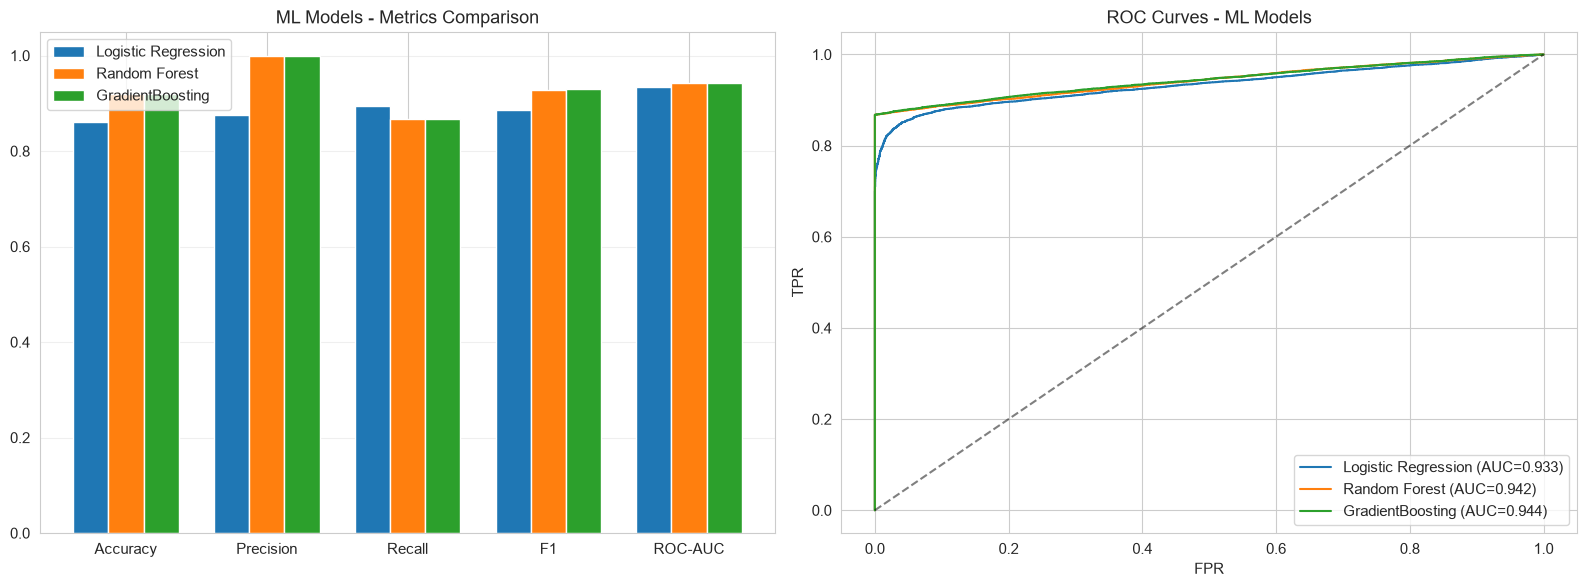

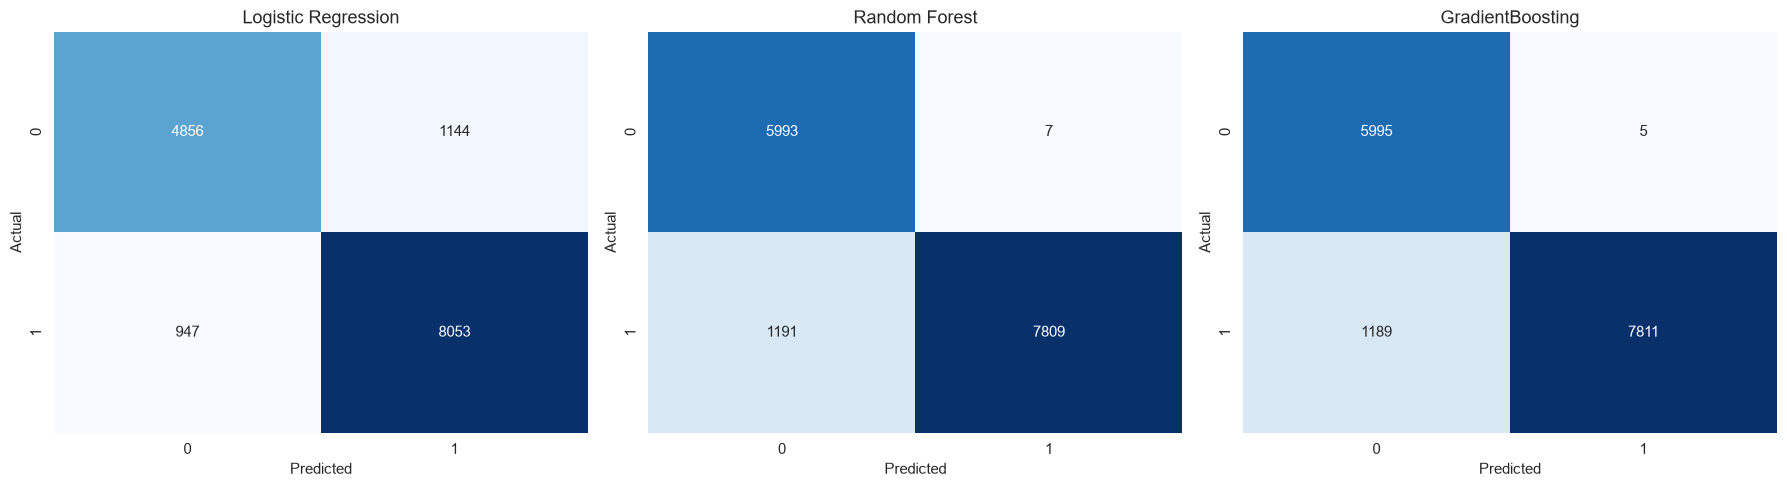

In [10]:
# ============================================================
# CELL 10: VISUALIZE ML RESULTS
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

# Bar chart of metrics
metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1',
    'ROC-AUC'
]

x = np.arange(len(metrics))
width = 0.25

for i, row in ml_df.iterrows():
    axes[0].bar(
        x + i * width,
        [row[m] for m in metrics],
        width,
        label=row['Model']
    )

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.05)
axes[0].set_title(
    'ML Models - Metrics Comparison'
)
axes[0].legend()
axes[0].grid(
    axis='y',
    alpha=0.3
)

# ROC curves
for name, prob in ml_probs.items():
    fpr, tpr, _ = roc_curve(
        y_test.ravel(),
        prob
    )

    auc = roc_auc_score(
        y_test.ravel(),
        prob
    )

    axes[1].plot(
        fpr,
        tpr,
        label=f'{name} (AUC={auc:.3f})'
    )

axes[1].plot(
    [0, 1],
    [0, 1],
    'k--',
    alpha=0.5
)

axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title(
    'ROC Curves - ML Models'
)
axes[1].legend()

plt.tight_layout()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(
    1,
    len(ml_df),
    figsize=(6 * len(ml_df), 5)
)

if len(ml_df) == 1:
    axes = [axes]

preds_all = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred
}

if HAS_XGB:
    preds_all['XGBoost'] = xgb_pred
else:
    preds_all['GradientBoosting'] = gb_pred

for i, (name, pred) in enumerate(preds_all.items()):
    cm = confusion_matrix(
        y_test.ravel(),
        pred
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        ax=axes[i],
        cmap='Blues',
        cbar=False
    )

    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# CELL 11: DEEP LEARNING FROM SCRATCH - 5 LAYER MLP
# NUMPY ONLY
# ============================================================

# Architecture:
# input -> 128 -> 64 -> 32 -> 16 -> 1
#
# Hidden layers: ReLU
# Output layer: Sigmoid
# Loss: Binary Cross-Entropy

class MLP5Layer:
    """
    5-layer MLP with ReLU hidden activations + Sigmoid output.

    Layers:
        input -> h1 -> h2 -> h3 -> h4 -> output
    """

    def __init__(
        self,
        input_dim,
        hidden_dims=(128, 64, 32, 16),
        seed=42
    ):
        rng = np.random.RandomState(seed)

        dims = [
            input_dim
        ] + list(hidden_dims) + [1]

        self.W = []
        self.b = []

        for i in range(len(dims) - 1):
            # He initialization
            scale = np.sqrt(
                2.0 / dims[i]
            )

            self.W.append(
                rng.randn(
                    dims[i],
                    dims[i + 1]
                ).astype(np.float32) * scale
            )

            self.b.append(
                np.zeros(
                    (1, dims[i + 1]),
                    dtype=np.float32
                )
            )

        self.num_layers = len(self.W)

    # --------------------------------------------------------
    # Activations
    # --------------------------------------------------------
    @staticmethod
    def relu(x):
        return np.maximum(0, x)

    @staticmethod
    def relu_deriv(x):
        return (
            x > 0
        ).astype(np.float32)

    @staticmethod
    def sigmoid(x):
        x = np.clip(x, -50, 50)
        return 1.0 / (
            1.0 + np.exp(-x)
        )

    # --------------------------------------------------------
    # Forward propagation
    # --------------------------------------------------------
    def forward(self, X):
        cache = {
            'A0': X
        }

        A = X

        # Hidden layers
        for i in range(
            self.num_layers - 1
        ):
            Z = (
                A @ self.W[i]
                + self.b[i]
            )

            A = self.relu(Z)

            cache[f'Z{i + 1}'] = Z
            cache[f'A{i + 1}'] = A

        # Output layer
        ZL = (
            A @ self.W[-1]
            + self.b[-1]
        )

        AL = self.sigmoid(ZL)

        cache[f'Z{self.num_layers}'] = ZL
        cache[f'A{self.num_layers}'] = AL

        return AL, cache

    # --------------------------------------------------------
    # Binary Cross-Entropy
    # --------------------------------------------------------
    @staticmethod
    def binary_cross_entropy(
        y,
        y_hat,
        eps=1e-8
    ):
        y_hat = np.clip(
            y_hat,
            eps,
            1 - eps
        )

        return -np.mean(
            y * np.log(y_hat)
            + (1 - y) * np.log(1 - y_hat)
        )

    # --------------------------------------------------------
    # Backpropagation
    # --------------------------------------------------------
    def backward(self, y, cache):
        m = y.shape[0]

        grads_W = [
            None
        ] * self.num_layers

        grads_b = [
            None
        ] * self.num_layers

        # Output layer:
        # sigmoid + BCE -> dZ = y_hat - y
        AL = cache[
            f'A{self.num_layers}'
        ]

        dZ = (
            AL - y
        ) / m

        A_prev = cache[
            f'A{self.num_layers - 1}'
        ]

        grads_W[-1] = (
            A_prev.T @ dZ
        )

        grads_b[-1] = np.sum(
            dZ,
            axis=0,
            keepdims=True
        )

        # Hidden layers
        for i in range(
            self.num_layers - 2,
            -1,
            -1
        ):
            dA = (
                dZ
                @ self.W[i + 1].T
            )

            Z = cache[
                f'Z{i + 1}'
            ]

            dZ = (
                dA
                * self.relu_deriv(Z)
            )

            A_prev = cache[
                f'A{i}'
            ]

            grads_W[i] = (
                A_prev.T @ dZ
            )

            grads_b[i] = np.sum(
                dZ,
                axis=0,
                keepdims=True
            )

        return grads_W, grads_b

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------
    def predict_proba(self, X):
        y_hat, _ = self.forward(X)
        return y_hat

    def predict(
        self,
        X,
        threshold=0.5
    ):
        return (
            self.predict_proba(X)
            >= threshold
        ).astype(int)


print("MLP5Layer class defined.")

MLP5Layer class defined.


In [12]:
# ============================================================
# 11. TRAINING LOOP WITH MINI-BATCH + ADAM & SGD
# ============================================================

def train_mlp(model, X_train, y_train, X_val, y_val,
              epochs=100, batch_size=128, lr=0.01,
              optimizer='adam', l2=0.0, verbose=True,
              patience=None, print_every=1):
    """
    Train MLP with mini-batch gradient descent.
    Supports SGD and Adam optimizers.

    Parameters
    ----------
    print_every : int
        In log mỗi `print_every` epoch. Mặc định = 1 (in mỗi epoch).
    patience : int or None
        Early stopping nếu val_loss không cải thiện sau `patience` epoch.

    Returns
    -------
    history : dict with keys 'train_loss', 'val_loss', 'train_acc', 'val_acc'
    """
    m = X_train.shape[0]
    n_batches = max(1, m // batch_size)

    # Optimizer state
    if optimizer == 'adam':
        beta1, beta2, eps = 0.9, 0.999, 1e-8
        mW = [np.zeros_like(w) for w in model.W]
        vW = [np.zeros_like(w) for w in model.W]
        mb = [np.zeros_like(b) for b in model.b]
        vb = [np.zeros_like(b) for b in model.b]
        t = 0

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = np.inf
    best_params = None
    wait = 0

    for epoch in range(epochs):
        # Shuffle
        idx = np.random.permutation(m)
        X_sh, y_sh = X_train[idx], y_train[idx]

        epoch_loss = 0.0
        for bidx in range(n_batches):
            start = bidx * batch_size
            end = min(start + batch_size, m)
            Xb = X_sh[start:end]
            yb = y_sh[start:end]

            y_hat, cache = model.forward(Xb)
            loss = model.binary_cross_entropy(yb, y_hat)
            epoch_loss += loss * (end - start)

            gW, gb = model.backward(yb, cache)

            # L2 regularization
            if l2 > 0:
                for i in range(model.num_layers):
                    gW[i] = gW[i] + l2 * model.W[i]

            if optimizer == 'sgd':
                for i in range(model.num_layers):
                    model.W[i] -= lr * gW[i]
                    model.b[i] -= lr * gb[i]
            elif optimizer == 'adam':
                t += 1
                for i in range(model.num_layers):
                    # --- W ---
                    mW[i] = beta1 * mW[i] + (1 - beta1) * gW[i]
                    vW[i] = beta2 * vW[i] + (1 - beta2) * (gW[i] ** 2)
                    mW_hat = mW[i] / (1 - beta1 ** t)
                    vW_hat = vW[i] / (1 - beta2 ** t)
                    model.W[i] -= lr * mW_hat / (np.sqrt(vW_hat) + eps)
                    # --- b ---
                    mb[i] = beta1 * mb[i] + (1 - beta1) * gb[i]
                    vb[i] = beta2 * vb[i] + (1 - beta2) * (gb[i] ** 2)
                    mb_hat = mb[i] / (1 - beta1 ** t)
                    vb_hat = vb[i] / (1 - beta2 ** t)
                    model.b[i] -= lr * mb_hat / (np.sqrt(vb_hat) + eps)

        epoch_loss /= m

        # ----- Evaluate trên train/val -----
        train_prob = model.predict_proba(X_train)
        val_prob = model.predict_proba(X_val)
        train_loss = model.binary_cross_entropy(y_train, train_prob)
        val_loss = model.binary_cross_entropy(y_val, val_prob)
        train_acc = ((train_prob >= 0.5).astype(int) == y_train).mean()
        val_acc = ((val_prob >= 0.5).astype(int) == y_val).mean()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # ----- Early stopping -----
        if patience is not None:
            if val_loss < best_val_loss - 1e-4:
                best_val_loss = val_loss
                best_params = ([w.copy() for w in model.W],
                               [b.copy() for b in model.b])
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    if verbose:
                        print(f"⏹  Early stopping tại epoch {epoch + 1}")
                    break

        # ----- IN LOG (MỖI EPOCH HOẶC MỖI print_every) -----
        if verbose and ((epoch + 1) % print_every == 0 or epoch == epochs - 1):
            print(f"Epoch {epoch + 1:4d}/{epochs} | "
                  f"TrainLoss={train_loss:.4f} | ValLoss={val_loss:.4f} | "
                  f"TrainAcc={train_acc:.4f} | ValAcc={val_acc:.4f} | "
                  f"wait={wait}")

    # ----- Restore best params -----
    if patience is not None and best_params is not None:
        model.W, model.b = best_params
        if verbose:
            print(f"✅ Restored best model (val_loss={best_val_loss:.4f})")

    return history


print("Training function ready (print_every=1 mặc định in mỗi epoch).")

Training function ready (print_every=1 mặc định in mỗi epoch).


In [13]:
# ============================================================
# CELL 13: TRAIN BASELINE DEEP LEARNING MODEL
# ============================================================

input_dim = X_train.shape[1]

print(f"Input dimension: {input_dim}")

np.random.seed(42)

baseline_model = MLP5Layer(
    input_dim=input_dim,
    hidden_dims=(128, 64, 32, 16),
    seed=42
)

t0 = time.time()

baseline_hist = train_mlp(
    baseline_model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=150,
    batch_size=128,
    lr=0.001,
    optimizer='adam',
    l2=1e-5,
    verbose=True,
    patience=20
)

print(
    f"\nTraining time: "
    f"{time.time() - t0:.2f}s"
)

# ------------------------------------------------------------
# Evaluation helper
# ------------------------------------------------------------
def full_eval(
    model,
    X,
    y,
    name
):
    prob = model.predict_proba(X)

    pred = (
        prob >= 0.5
    ).astype(int)

    return (
        evaluate_model(
            name,
            y.ravel(),
            pred.ravel(),
            prob.ravel()
        ),
        pred,
        prob
    )

baseline_metrics, baseline_pred, baseline_prob = full_eval(
    baseline_model,
    X_test,
    y_test,
    'MLP Baseline'
)

print("\nBaseline MLP Test:")
print(baseline_metrics)

Input dimension: 47
Epoch    1/150 | TrainLoss=0.2808 | ValLoss=0.2904 | TrainAcc=0.8817 | ValAcc=0.8762 | wait=0
Epoch    2/150 | TrainLoss=0.2479 | ValLoss=0.2645 | TrainAcc=0.9004 | ValAcc=0.8907 | wait=0
Epoch    3/150 | TrainLoss=0.2425 | ValLoss=0.2628 | TrainAcc=0.9023 | ValAcc=0.8923 | wait=0
Epoch    4/150 | TrainLoss=0.2267 | ValLoss=0.2525 | TrainAcc=0.9097 | ValAcc=0.8972 | wait=0
Epoch    5/150 | TrainLoss=0.2219 | ValLoss=0.2533 | TrainAcc=0.9110 | ValAcc=0.8985 | wait=1
Epoch    6/150 | TrainLoss=0.2172 | ValLoss=0.2489 | TrainAcc=0.9147 | ValAcc=0.9001 | wait=0
Epoch    7/150 | TrainLoss=0.2122 | ValLoss=0.2483 | TrainAcc=0.9163 | ValAcc=0.9019 | wait=0
Epoch    8/150 | TrainLoss=0.2096 | ValLoss=0.2551 | TrainAcc=0.9179 | ValAcc=0.9015 | wait=1
Epoch    9/150 | TrainLoss=0.2127 | ValLoss=0.2574 | TrainAcc=0.9157 | ValAcc=0.8995 | wait=2
Epoch   10/150 | TrainLoss=0.2082 | ValLoss=0.2597 | TrainAcc=0.9171 | ValAcc=0.9014 | wait=3
Epoch   11/150 | TrainLoss=0.1980 | ValL

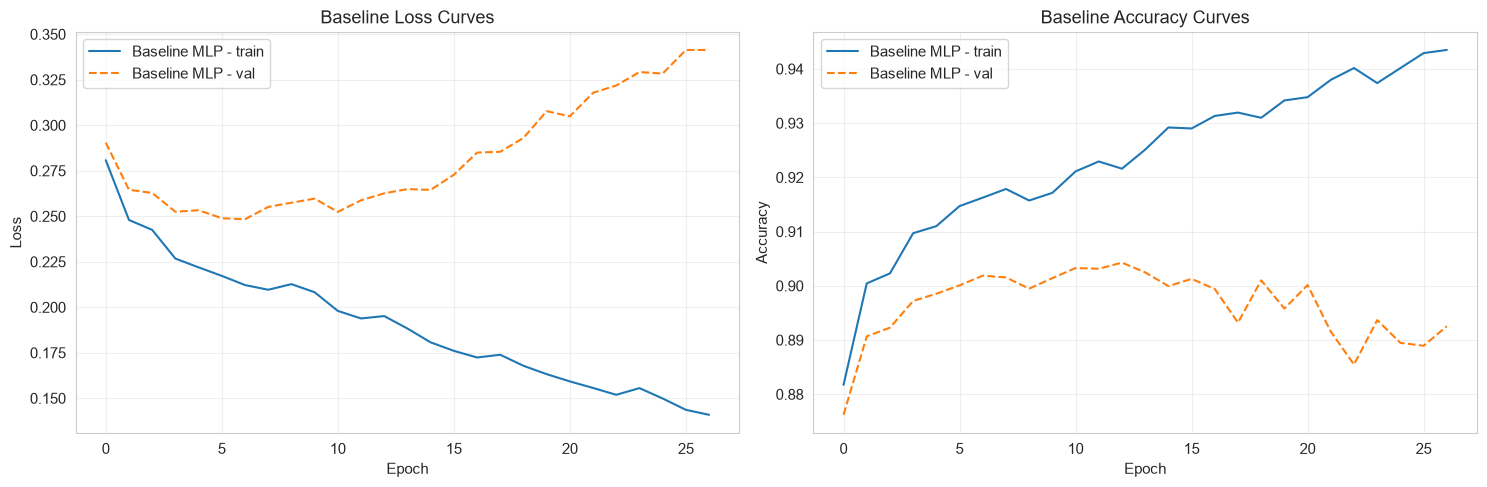

In [14]:
# ============================================================
# CELL 14: VISUALIZE BASELINE TRAINING
# ============================================================

def plot_history(
    histories,
    labels,
    title_prefix=""
):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 5)
    )

    for hist, lbl in zip(
        histories,
        labels
    ):
        axes[0].plot(
            hist['train_loss'],
            label=f'{lbl} - train'
        )

        axes[0].plot(
            hist['val_loss'],
            label=f'{lbl} - val',
            linestyle='--'
        )

        axes[1].plot(
            hist['train_acc'],
            label=f'{lbl} - train'
        )

        axes[1].plot(
            hist['val_acc'],
            label=f'{lbl} - val',
            linestyle='--'
        )

    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(
        f'{title_prefix} Loss Curves'
    )
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(
        f'{title_prefix} Accuracy Curves'
    )
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_history(
    [baseline_hist],
    ['Baseline MLP'],
    'Baseline'
)


===== TRAINING WITH LR = 0.0001 =====
Epoch    5/40 | TrainLoss=0.2943 | ValLoss=0.3047 | TrainAcc=0.8747 | ValAcc=0.8686 | wait=0
Epoch   10/40 | TrainLoss=0.2599 | ValLoss=0.2784 | TrainAcc=0.8939 | ValAcc=0.8846 | wait=0
Epoch   15/40 | TrainLoss=0.2415 | ValLoss=0.2658 | TrainAcc=0.9020 | ValAcc=0.8907 | wait=0
Epoch   20/40 | TrainLoss=0.2307 | ValLoss=0.2604 | TrainAcc=0.9072 | ValAcc=0.8937 | wait=0
Epoch   25/40 | TrainLoss=0.2229 | ValLoss=0.2595 | TrainAcc=0.9109 | ValAcc=0.8944 | wait=0
Epoch   30/40 | TrainLoss=0.2169 | ValLoss=0.2591 | TrainAcc=0.9144 | ValAcc=0.8958 | wait=2
Epoch   35/40 | TrainLoss=0.2109 | ValLoss=0.2632 | TrainAcc=0.9155 | ValAcc=0.8973 | wait=7
⏹  Early stopping tại epoch 38
✅ Restored best model (val_loss=0.2589)
⏱  LR=0.0001 xong sau 118.6s (38 epochs)

===== TRAINING WITH LR = 0.001 =====
Epoch    5/40 | TrainLoss=0.2219 | ValLoss=0.2533 | TrainAcc=0.9110 | ValAcc=0.8985 | wait=1
Epoch   10/40 | TrainLoss=0.2082 | ValLoss=0.2597 | TrainAcc=0.9171

,LR,Epochs,Time(s),Accuracy,Precision,Recall,F1,ROC-AUC
0,0.0001,38,118.638873,0.898000,0.973264,0.853444,0.909425,0.934298
1,0.0010,17,56.475321,0.903667,0.978953,0.857889,0.914431,0.937382
2,0.0100,27,84.544646,0.914133,0.990086,0.865556,0.923642,0.940735
3,0.0500,26,61.376533,0.911733,0.981677,0.869111,0.921971,0.939365


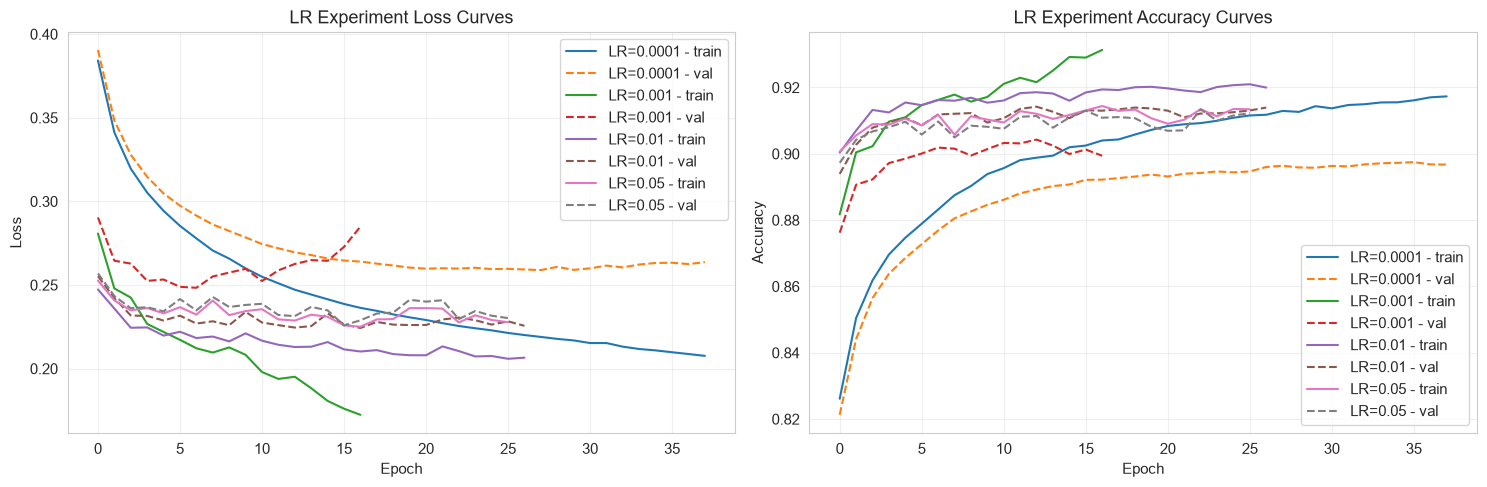

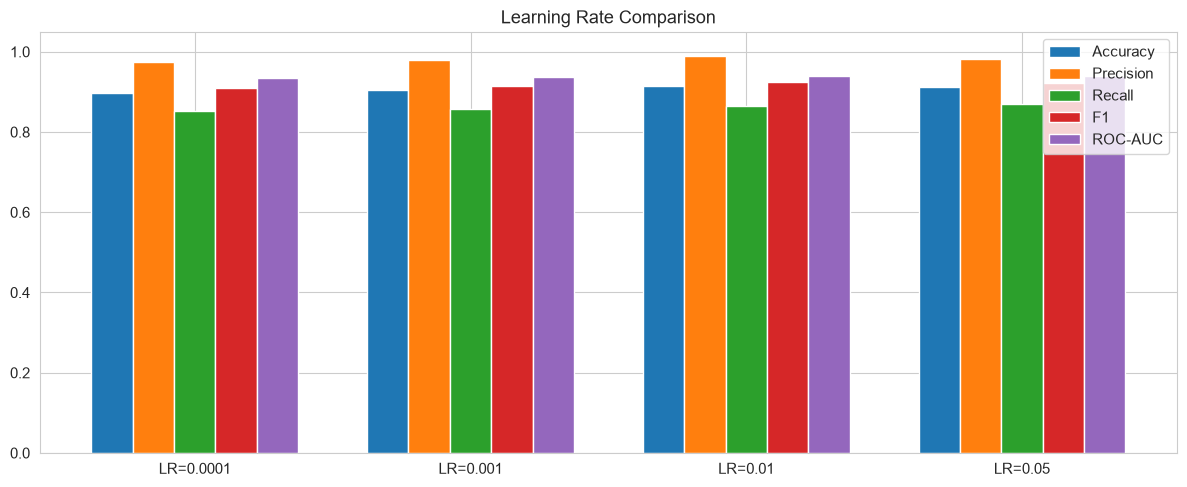

In [16]:
# ============================================================
# CELL 15: HYPERPARAMETER EXPERIMENT 1 - LEARNING RATE
# ============================================================

import time

learning_rates = [0.0001, 0.001, 0.01, 0.05]

lr_histories = {}
lr_models = {}
lr_results = []

for lr in learning_rates:
    print(f"\n{'='*60}")
    print(f"===== TRAINING WITH LR = {lr} =====")
    print(f"{'='*60}")

    np.random.seed(42)

    model = MLP5Layer(
        input_dim=input_dim,
        hidden_dims=(128, 64, 32, 16),
        seed=42
    )

    t0 = time.time()

    hist = train_mlp(
        model,
        X_train, y_train,
        X_val, y_val,
        epochs=40,              # ⚡ giảm 80 → 40
        batch_size=128,
        lr=lr,
        optimizer='adam',
        l2=1e-5,
        verbose=True,           # ⚡ bật log
        print_every=5,          # ⚡ in mỗi 5 epoch
        patience=10             # ⚡ early stopping
    )

    elapsed = time.time() - t0
    print(f"⏱  LR={lr} xong sau {elapsed:.1f}s "
          f"({len(hist['train_loss'])} epochs)")

    lr_histories[lr] = hist
    lr_models[lr] = model

    m, _, _ = full_eval(model, X_test, y_test, f'LR={lr}')
    m['LR'] = lr
    m['Time(s)'] = elapsed
    m['Epochs'] = len(hist['train_loss'])
    lr_results.append(m)

lr_df = pd.DataFrame(lr_results)[
    ['LR', 'Epochs', 'Time(s)',
     'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
]

print("\n=== Learning Rate Comparison ===")
display(lr_df)

plot_history(
    list(lr_histories.values()),
    [f'LR={lr}' for lr in learning_rates],
    'LR Experiment'
)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(lr_df))
w = 0.15
for i, m in enumerate(['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']):
    ax.bar(x + i * w, lr_df[m], w, label=m)
ax.set_xticks(x + 2 * w)
ax.set_xticklabels([f'LR={lr}' for lr in lr_df['LR']])
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title('Learning Rate Comparison')
plt.tight_layout()
plt.show()


===== BATCH SIZE = 64 =====
Epoch    5/30 | TrainLoss=0.2263 | ValLoss=0.2554 | TrainAcc=0.9107 | ValAcc=0.9011 | wait=2
Epoch   10/30 | TrainLoss=0.2013 | ValLoss=0.2532 | TrainAcc=0.9221 | ValAcc=0.9063 | wait=3
⏹  Early stopping tại epoch 15
✅ Restored best model (val_loss=0.2418)
⏱  BS=64 xong sau 43.7s (15 epochs)

===== BATCH SIZE = 128 =====
Epoch    5/30 | TrainLoss=0.2219 | ValLoss=0.2533 | TrainAcc=0.9110 | ValAcc=0.8985 | wait=1
Epoch   10/30 | TrainLoss=0.2082 | ValLoss=0.2597 | TrainAcc=0.9171 | ValAcc=0.9014 | wait=3
⏹  Early stopping tại epoch 15
✅ Restored best model (val_loss=0.2483)
⏱  BS=128 xong sau 31.1s (15 epochs)

===== BATCH SIZE = 256 =====
Epoch    5/30 | TrainLoss=0.2286 | ValLoss=0.2613 | TrainAcc=0.9080 | ValAcc=0.8963 | wait=1
Epoch   10/30 | TrainLoss=0.2067 | ValLoss=0.2603 | TrainAcc=0.9184 | ValAcc=0.8998 | wait=3
⏹  Early stopping tại epoch 15
✅ Restored best model (val_loss=0.2526)
⏱  BS=256 xong sau 22.6s (15 epochs)

===== BATCH SIZE = 512 =====


,BatchSize,Epochs,Time(s),Accuracy,Precision,Recall,F1,ROC-AUC
0,64,15,43.665627,0.906800,0.980288,0.862000,0.917347,0.938272
1,128,15,31.101190,0.903667,0.978953,0.857889,0.914431,0.937382
2,256,15,22.621473,0.900133,0.980159,0.850778,0.910897,0.935609
3,512,15,27.519080,0.897533,0.971924,0.853889,0.909091,0.935376


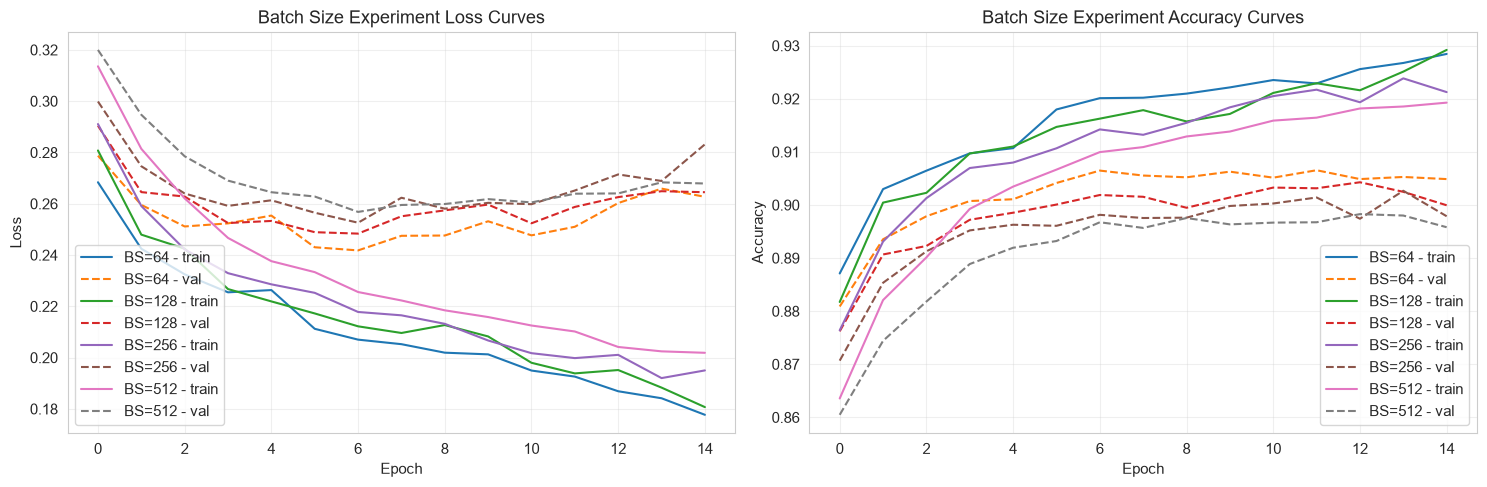

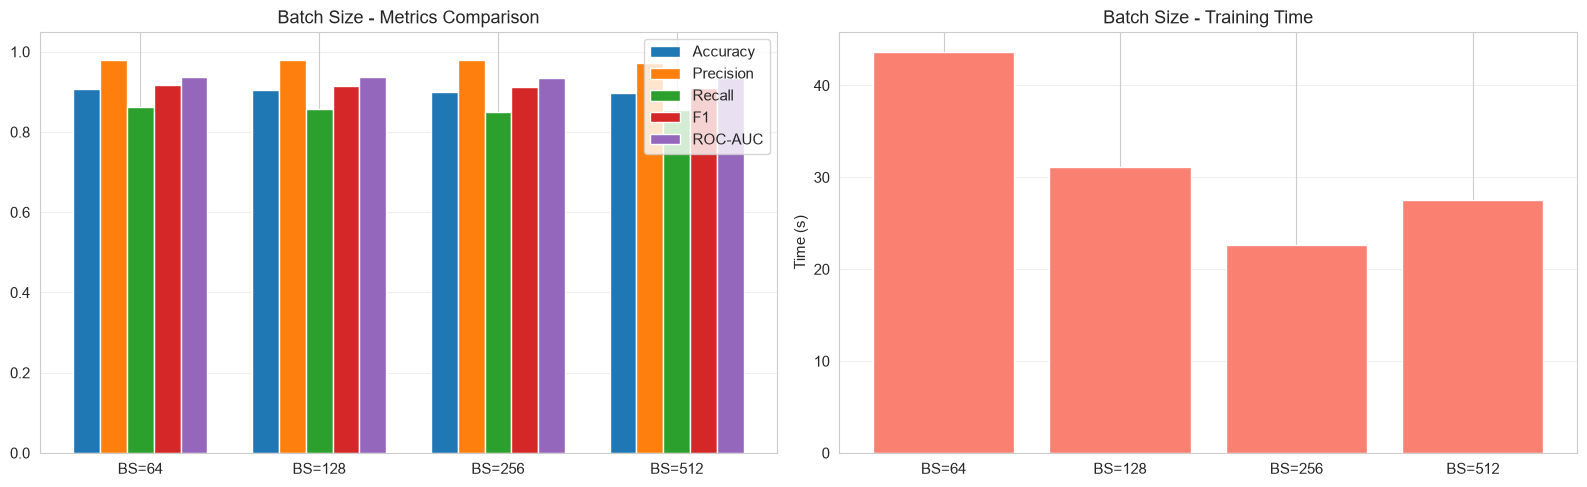

In [18]:
# ============================================================
# CELL 16: HYPERPARAMETER EXPERIMENT 2 - BATCH SIZE (OPTIMIZED)
# ============================================================

import time

# ⚡ Giảm số batch size thử + tăng min size để tránh BS quá nhỏ
batch_sizes = [64, 128, 256, 512]     # bỏ 32 (chậm nhất, thường không tốt hơn)

bs_histories = {}
bs_results = []

for bs in batch_sizes:
    print(f"\n{'='*60}")
    print(f"===== BATCH SIZE = {bs} =====")
    print(f"{'='*60}")

    np.random.seed(42)
    model = MLP5Layer(
        input_dim=input_dim,
        hidden_dims=(128, 64, 32, 16),
        seed=42
    )

    t0 = time.time()

    hist = train_mlp(
        model,
        X_train, y_train,
        X_val, y_val,
        epochs=30,              # ⚡ giảm 60 → 30 (đủ để thấy xu hướng)
        batch_size=bs,
        lr=0.001,
        optimizer='adam',
        l2=1e-5,
        verbose=True,           # ⚡ bật log
        print_every=5,          # ⚡ log mỗi 5 epoch
        patience=8              # ⚡ early stopping
    )

    elapsed = time.time() - t0
    print(f"⏱  BS={bs} xong sau {elapsed:.1f}s "
          f"({len(hist['train_loss'])} epochs)")

    bs_histories[bs] = hist

    m, _, _ = full_eval(model, X_test, y_test, f'BS={bs}')
    m['BatchSize'] = bs
    m['Time(s)'] = elapsed
    m['Epochs'] = len(hist['train_loss'])
    bs_results.append(m)

bs_df = pd.DataFrame(bs_results)[
    ['BatchSize', 'Epochs', 'Time(s)',
     'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
].sort_values('BatchSize')

print("\n=== Batch Size Comparison ===")
display(bs_df)

plot_history(
    list(bs_histories.values()),
    [f'BS={bs}' for bs in bs_df['BatchSize']],
    'Batch Size Experiment'
)

# --- Bar chart metrics ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(bs_df))
w = 0.15
for i, m in enumerate(['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']):
    axes[0].bar(x + i * w, bs_df[m], w, label=m)
axes[0].set_xticks(x + 2 * w)
axes[0].set_xticklabels([f'BS={bs}' for bs in bs_df['BatchSize']])
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].set_title('Batch Size - Metrics Comparison')
axes[0].grid(axis='y', alpha=0.3)

# --- Bar chart time ---
axes[1].bar([f'BS={bs}' for bs in bs_df['BatchSize']],
            bs_df['Time(s)'], color='salmon')
axes[1].set_ylabel('Time (s)')
axes[1].set_title('Batch Size - Training Time')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


===== ARCH = Shallow (64) =====
  → Number of parameters: 3,137
Epoch    5/30 | TrainLoss=0.2476 | ValLoss=0.2557 | TrainAcc=0.9036 | ValAcc=0.8985 | wait=0
Epoch   10/30 | TrainLoss=0.2242 | ValLoss=0.2349 | TrainAcc=0.9132 | ValAcc=0.9097 | wait=0
Epoch   15/30 | TrainLoss=0.2156 | ValLoss=0.2277 | TrainAcc=0.9162 | ValAcc=0.9133 | wait=0
Epoch   20/30 | TrainLoss=0.2102 | ValLoss=0.2253 | TrainAcc=0.9177 | ValAcc=0.9151 | wait=0
Epoch   25/30 | TrainLoss=0.2073 | ValLoss=0.2260 | TrainAcc=0.9188 | ValAcc=0.9147 | wait=2
Epoch   30/30 | TrainLoss=0.2042 | ValLoss=0.2253 | TrainAcc=0.9196 | ValAcc=0.9155 | wait=7
✅ Restored best model (val_loss=0.2243)
⏱  Shallow (64) xong sau 12.1s (30 epochs)

===== ARCH = Baseline 5L (128,64,32,16) =====
  → Number of parameters: 17,025
Epoch    5/30 | TrainLoss=0.2219 | ValLoss=0.2533 | TrainAcc=0.9110 | ValAcc=0.8985 | wait=1
Epoch   10/30 | TrainLoss=0.2082 | ValLoss=0.2597 | TrainAcc=0.9171 | ValAcc=0.9014 | wait=3
⏹  Early stopping tại epoch 

,Arch,Params,Epochs,Time(s),Accuracy,Precision,Recall,F1,ROC-AUC
0,Shallow (64),3137,30,12.140475,0.914733,0.988362,0.868111,0.924342,0.939604
1,"Baseline 5L (128,64,32,16)",17025,15,36.580128,0.903667,0.978953,0.857889,0.914431,0.937382
2,"Wide (256,128,64,32)",55553,13,73.353419,0.904200,0.977764,0.859889,0.915046,0.939305
3,"Deeper (128,128,64,32,16)",33537,15,82.501997,0.903933,0.978478,0.858778,0.914729,0.936289
4,"Narrow (32,16,8,4)",2241,30,15.534658,0.911467,0.987421,0.863444,0.921280,0.940018


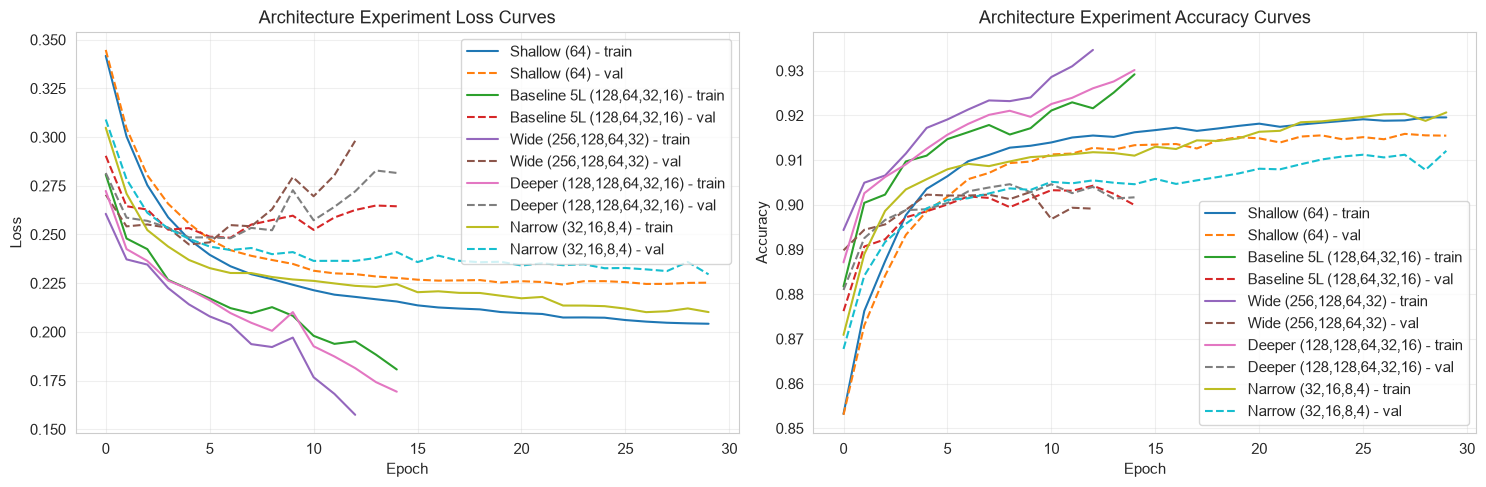

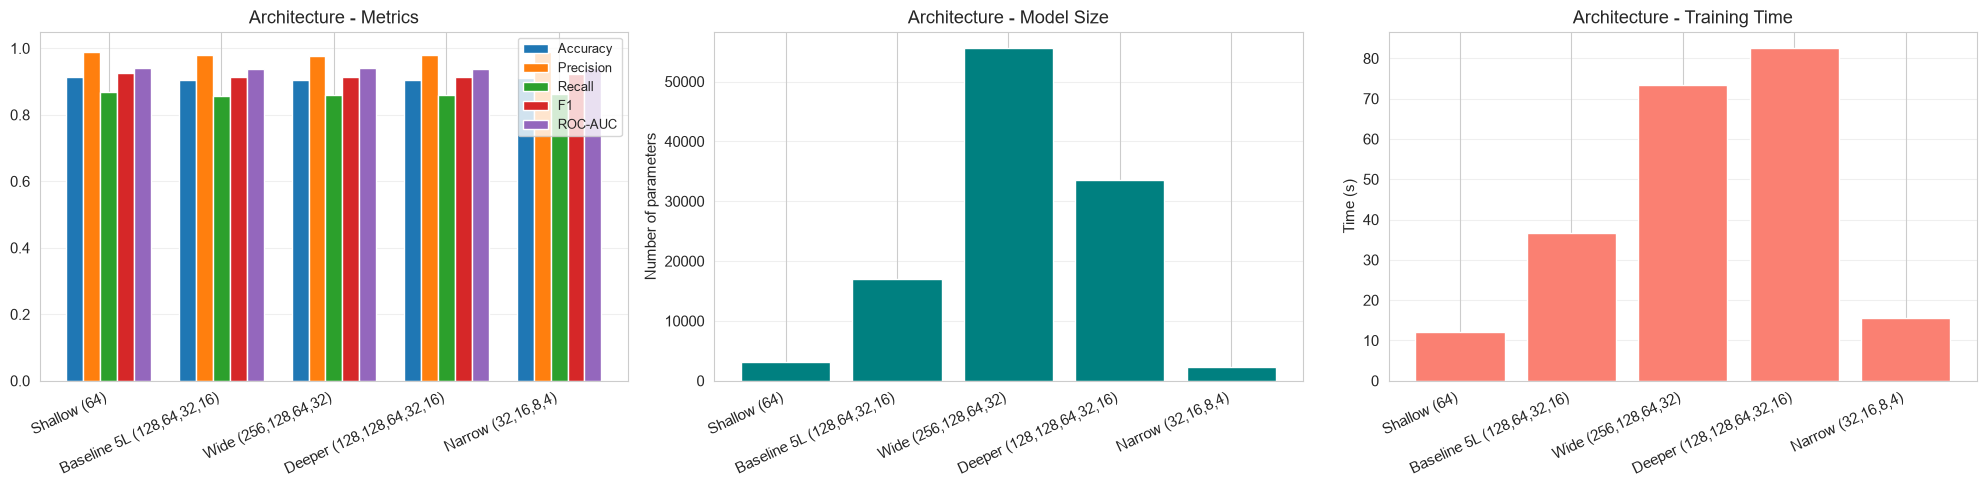

In [19]:
# ============================================================
# CELL 17: HYPERPARAMETER EXPERIMENT 3 - ARCHITECTURE (OPTIMIZED)
# ============================================================

import time

architectures = {
    'Shallow (64)':              (64,),
    'Baseline 5L (128,64,32,16)': (128, 64, 32, 16),
    'Wide (256,128,64,32)':      (256, 128, 64, 32),
    'Deeper (128,128,64,32,16)': (128, 128, 64, 32, 16),
    'Narrow (32,16,8,4)':        (32, 16, 8, 4),
}

arch_histories = {}
arch_results = []

for name, dims in architectures.items():
    print(f"\n{'='*60}")
    print(f"===== ARCH = {name} =====")
    print(f"{'='*60}")

    np.random.seed(42)
    model = MLP5Layer(
        input_dim=input_dim,
        hidden_dims=dims,
        seed=42
    )

    n_params = sum(w.size for w in model.W) + sum(b.size for b in model.b)
    print(f"  → Number of parameters: {n_params:,}")

    t0 = time.time()

    hist = train_mlp(
        model,
        X_train, y_train,
        X_val, y_val,
        epochs=30,              # ⚡ giảm 60 → 30
        batch_size=128,
        lr=0.001,
        optimizer='adam',
        l2=1e-5,
        verbose=True,           # ⚡ bật log
        print_every=5,          # ⚡ log mỗi 5 epoch
        patience=8              # ⚡ early stopping
    )

    elapsed = time.time() - t0
    print(f"⏱  {name} xong sau {elapsed:.1f}s "
          f"({len(hist['train_loss'])} epochs)")

    arch_histories[name] = hist

    m, _, _ = full_eval(model, X_test, y_test, name)
    m['Arch'] = name
    m['Params'] = n_params
    m['Time(s)'] = elapsed
    m['Epochs'] = len(hist['train_loss'])
    arch_results.append(m)

arch_df = pd.DataFrame(arch_results)[
    ['Arch', 'Params', 'Epochs', 'Time(s)',
     'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
]

print("\n=== Architecture Comparison ===")
display(arch_df)

plot_history(
    list(arch_histories.values()),
    list(architectures.keys()),
    'Architecture Experiment'
)

# --- Bar chart metrics + params/time ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# (1) Metrics
x = np.arange(len(arch_df))
w = 0.15
for i, m in enumerate(['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']):
    axes[0].bar(x + i * w, arch_df[m], w, label=m)
axes[0].set_xticks(x + 2 * w)
axes[0].set_xticklabels(arch_df['Arch'], rotation=25, ha='right')
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9)
axes[0].set_title('Architecture - Metrics')
axes[0].grid(axis='y', alpha=0.3)

# (2) Params
axes[1].bar(arch_df['Arch'], arch_df['Params'], color='teal')
axes[1].set_xticklabels(arch_df['Arch'], rotation=25, ha='right')
axes[1].set_ylabel('Number of parameters')
axes[1].set_title('Architecture - Model Size')
axes[1].grid(axis='y', alpha=0.3)

# (3) Time
axes[2].bar(arch_df['Arch'], arch_df['Time(s)'], color='salmon')
axes[2].set_xticklabels(arch_df['Arch'], rotation=25, ha='right')
axes[2].set_ylabel('Time (s)')
axes[2].set_title('Architecture - Training Time')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


===== OPTIMIZER = SGD =====
  → Learning rate = 0.05
Epoch    5/50 | TrainLoss=0.2593 | ValLoss=0.2751 | TrainAcc=0.8920 | ValAcc=0.8853 | wait=0
Epoch   10/50 | TrainLoss=0.2365 | ValLoss=0.2639 | TrainAcc=0.9070 | ValAcc=0.8953 | wait=1
Epoch   15/50 | TrainLoss=0.2228 | ValLoss=0.2594 | TrainAcc=0.9101 | ValAcc=0.8974 | wait=3
Epoch   20/50 | TrainLoss=0.2159 | ValLoss=0.2611 | TrainAcc=0.9145 | ValAcc=0.8979 | wait=2
Epoch   25/50 | TrainLoss=0.2087 | ValLoss=0.2617 | TrainAcc=0.9166 | ValAcc=0.8978 | wait=7
⏹  Early stopping tại epoch 28
✅ Restored best model (val_loss=0.2571)
⏱  SGD xong sau 56.5s (28 epochs)

===== OPTIMIZER = ADAM =====
  → Learning rate = 0.001
Epoch    5/50 | TrainLoss=0.2219 | ValLoss=0.2533 | TrainAcc=0.9110 | ValAcc=0.8985 | wait=1
Epoch   10/50 | TrainLoss=0.2082 | ValLoss=0.2597 | TrainAcc=0.9171 | ValAcc=0.9014 | wait=3
Epoch   15/50 | TrainLoss=0.1807 | ValLoss=0.2645 | TrainAcc=0.9292 | ValAcc=0.8999 | wait=8
⏹  Early stopping tại epoch 17
✅ Restored

,Optimizer,LR,Epochs,Time(s),Accuracy,Precision,Recall,F1,ROC-AUC
0,sgd,0.050,28,56.527516,0.897400,0.980178,0.846111,0.908224,0.933673
1,adam,0.001,17,40.948896,0.903667,0.978953,0.857889,0.914431,0.937382


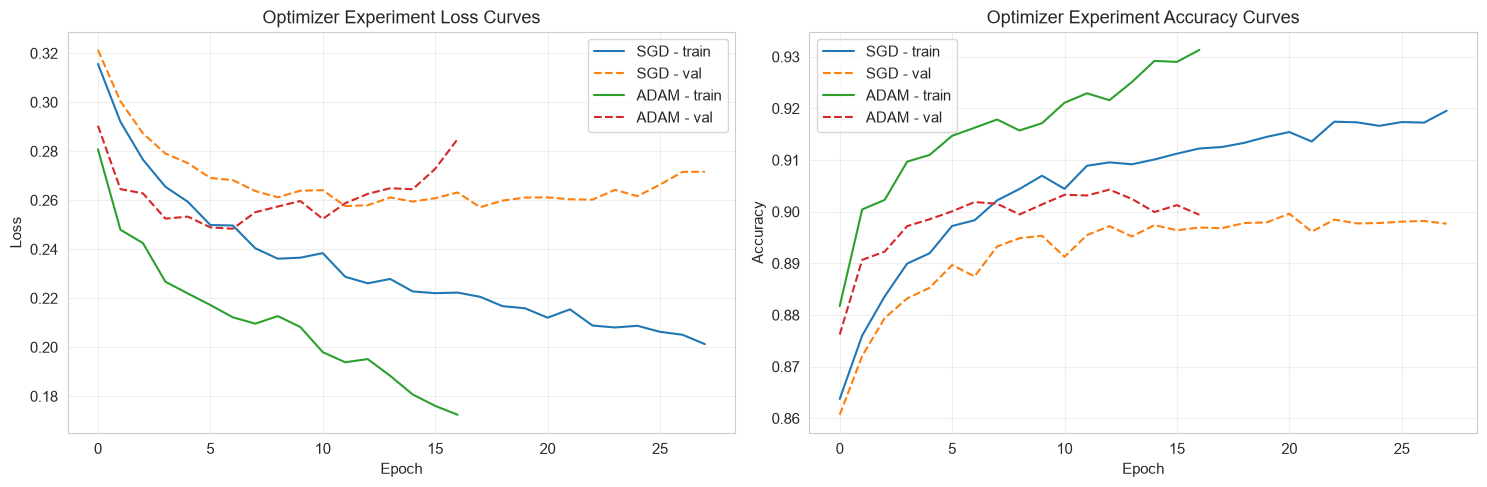

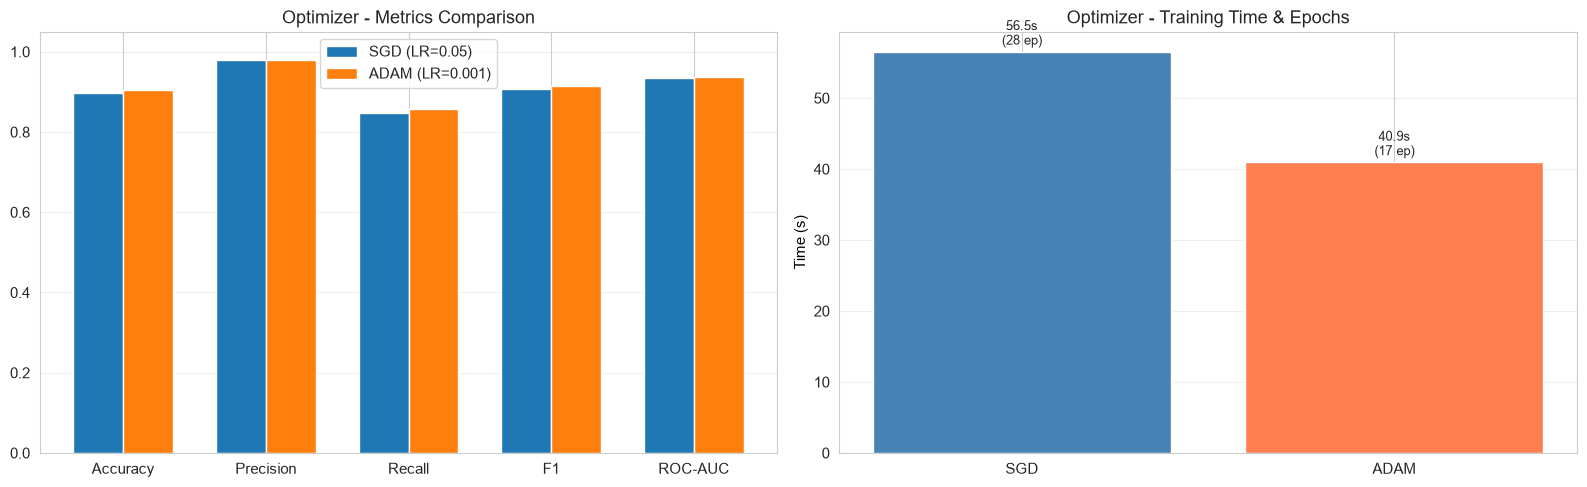

In [20]:
# ============================================================
# CELL 18: HYPERPARAMETER EXPERIMENT 4 - OPTIMIZER (OPTIMIZED)
# ============================================================

import time

optimizers = ['sgd', 'adam']
opt_histories = {}
opt_results = []

for opt in optimizers:
    print(f"\n{'='*60}")
    print(f"===== OPTIMIZER = {opt.upper()} =====")
    print(f"{'='*60}")

    np.random.seed(42)
    model = MLP5Layer(
        input_dim=input_dim,
        hidden_dims=(128, 64, 32, 16),
        seed=42
    )

    # SGD cần LR lớn hơn Adam
    lr_use = 0.05 if opt == 'sgd' else 0.001
    print(f"  → Learning rate = {lr_use}")

    t0 = time.time()

    hist = train_mlp(
        model,
        X_train, y_train,
        X_val, y_val,
        epochs=50,              # ⚡ giảm 80 → 50 (SGD cần nhiều epoch)
        batch_size=128,
        lr=lr_use,
        optimizer=opt,
        l2=1e-5,
        verbose=True,           # ⚡ bật log
        print_every=5,          # ⚡ log mỗi 5 epoch
        patience=10             # ⚡ early stopping (Adam sẽ dừng sớm)
    )

    elapsed = time.time() - t0
    print(f"⏱  {opt.upper()} xong sau {elapsed:.1f}s "
          f"({len(hist['train_loss'])} epochs)")

    opt_histories[opt] = hist

    m, _, _ = full_eval(model, X_test, y_test, f'Opt={opt}')
    m['Optimizer'] = opt
    m['LR'] = lr_use
    m['Time(s)'] = elapsed
    m['Epochs'] = len(hist['train_loss'])
    opt_results.append(m)

opt_df = pd.DataFrame(opt_results)[
    ['Optimizer', 'LR', 'Epochs', 'Time(s)',
     'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
]

print("\n=== Optimizer Comparison ===")
display(opt_df)

plot_history(
    list(opt_histories.values()),
    [o.upper() for o in optimizers],
    'Optimizer Experiment'
)

# --- Bar chart: metrics + time ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (1) Metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics))
w = 0.35
for i, row in opt_df.iterrows():
    axes[0].bar(x + i * w, [row[m] for m in metrics], w,
                label=f"{row['Optimizer'].upper()} (LR={row['LR']})")
axes[0].set_xticks(x + w / 2)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].set_title('Optimizer - Metrics Comparison')
axes[0].grid(axis='y', alpha=0.3)

# (2) Time + Epochs
ax2 = axes[1]
x2 = np.arange(len(opt_df))
bars = ax2.bar(x2, opt_df['Time(s)'], color=['steelblue', 'coral'])
ax2.set_xticks(x2)
ax2.set_xticklabels([o.upper() for o in opt_df['Optimizer']])
ax2.set_ylabel('Time (s)', color='black')
ax2.set_title('Optimizer - Training Time & Epochs')
for i, (t, e) in enumerate(zip(opt_df['Time(s)'], opt_df['Epochs'])):
    ax2.text(i, t + 1, f'{t:.1f}s\n({e} ep)', ha='center', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# CELL 19: BEST MODEL SELECTION & FINAL EVALUATION
# ============================================================

# Collect all DL experiments
all_dl = []

for m in lr_results:
    all_dl.append({
        **m,
        'Experiment': 'LR'
    })

for m in bs_results:
    all_dl.append({
        **m,
        'Experiment': 'BatchSize'
    })

for m in arch_results:
    all_dl.append({
        **m,
        'Experiment': 'Architecture'
    })

for m in opt_results:
    all_dl.append({
        **m,
        'Experiment': 'Optimizer'
    })

dl_df = pd.DataFrame(all_dl)

print("=== All DL Experiments ===")

display(
    dl_df.sort_values(
        'F1',
        ascending=False
    ).head(15)
)

# Pick best by F1
best_idx = dl_df['F1'].idxmax()
best_row = dl_df.loc[best_idx]

print("\nBest DL configuration:")
print(best_row)

=== All DL Experiments ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,LR,Time(s),Epochs,Experiment,BatchSize,Arch,Params,Optimizer
8,Shallow (64),0.914733,0.988362,0.868111,0.924342,0.939604,NaN,12.140475,30,Architecture,NaN,Shallow (64),3137.0,NaN
2,LR=0.01,0.914133,0.990086,0.865556,0.923642,0.940735,0.0100,84.544646,27,LR,NaN,NaN,NaN,NaN
3,LR=0.05,0.911733,0.981677,0.869111,0.921971,0.939365,0.0500,61.376533,26,LR,NaN,NaN,NaN,NaN
12,"Narrow (32,16,8,4)",0.911467,0.987421,0.863444,0.921280,0.940018,NaN,15.534658,30,Architecture,NaN,"Narrow (32,16,8,4)",2241.0,NaN
4,BS=64,0.906800,0.980288,0.862000,0.917347,0.938272,NaN,43.665627,15,BatchSize,64.0,NaN,NaN,NaN
10,"Wide (256,128,64,32)",0.904200,0.977764,0.859889,0.915046,0.939305,NaN,73.353419,13,Architecture,NaN,"Wide (256,128,64,32)",55553.0,NaN
11,"Deeper (128,128,64,32,16)",0.903933,0.978478,0.858778,0.914729,0.936289,NaN,82.501997,15,Architecture,NaN,"Deeper (128,128,64,32,16)",33537.0,NaN
14,Opt=adam,0.903667,0.978953,0.857889,0.914431,0.937382,0.0010,40.948896,17,Optimizer,NaN,NaN,NaN,adam
9,"Baseline 5L (128,64,32,16)",0.903667,0.978953,0.857889,0.914431,0.937382,NaN,36.580128,15,Architecture,NaN,"Baseline 5L (128,64,32,16)",17025.0,NaN
1,LR=0.001,0.903667,0.978953,0.857889,0.914431,0.937382,0.0010,56.475321,17,LR,NaN,NaN,NaN,NaN



Best DL configuration:
Model         Shallow (64)
Accuracy          0.914733
Precision         0.988362
Recall            0.868111
F1                0.924342
ROC-AUC           0.939604
LR                     NaN
Time(s)          12.140475
Epochs                  30
Experiment    Architecture
BatchSize              NaN
Arch          Shallow (64)
Params              3137.0
Optimizer              NaN
Name: 8, dtype: object


In [23]:
# ============================================================
# CELL 20: RETRAIN BEST CONFIG WITH MORE EPOCHS
# ============================================================

# The original experimental design selects:
# Adam, lr=0.001, batch=128,
# baseline architecture (128,64,32,16),
# with early stopping.

np.random.seed(42)

best_model = MLP5Layer(
    input_dim=input_dim,
    hidden_dims=(128, 64, 32, 16),
    seed=42
)

best_hist = train_mlp(
    best_model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=200,
    batch_size=128,
    lr=0.001,
    optimizer='adam',
    l2=1e-5,
    verbose=True,
    patience=25
)

dl_metrics, dl_pred, dl_prob = full_eval(
    best_model,
    X_test,
    y_test,
    'Best MLP'
)

print("\nFinal DL Test Metrics:")

for k, v in dl_metrics.items():
    print(f"  {k}: {v}")

print("\nClassification Report:")

print(
    classification_report(
        y_test.ravel(),
        dl_pred.ravel(),
        target_names=[
            'No Diabetes',
            'Diabetes'
        ]
    )
)

Epoch    1/200 | TrainLoss=0.2808 | ValLoss=0.2904 | TrainAcc=0.8817 | ValAcc=0.8762 | wait=0
Epoch    2/200 | TrainLoss=0.2479 | ValLoss=0.2645 | TrainAcc=0.9004 | ValAcc=0.8907 | wait=0
Epoch    3/200 | TrainLoss=0.2425 | ValLoss=0.2628 | TrainAcc=0.9023 | ValAcc=0.8923 | wait=0
Epoch    4/200 | TrainLoss=0.2267 | ValLoss=0.2525 | TrainAcc=0.9097 | ValAcc=0.8972 | wait=0
Epoch    5/200 | TrainLoss=0.2219 | ValLoss=0.2533 | TrainAcc=0.9110 | ValAcc=0.8985 | wait=1
Epoch    6/200 | TrainLoss=0.2172 | ValLoss=0.2489 | TrainAcc=0.9147 | ValAcc=0.9001 | wait=0
Epoch    7/200 | TrainLoss=0.2122 | ValLoss=0.2483 | TrainAcc=0.9163 | ValAcc=0.9019 | wait=0
Epoch    8/200 | TrainLoss=0.2096 | ValLoss=0.2551 | TrainAcc=0.9179 | ValAcc=0.9015 | wait=1
Epoch    9/200 | TrainLoss=0.2127 | ValLoss=0.2574 | TrainAcc=0.9157 | ValAcc=0.8995 | wait=2
Epoch   10/200 | TrainLoss=0.2082 | ValLoss=0.2597 | TrainAcc=0.9171 | ValAcc=0.9014 | wait=3
Epoch   11/200 | TrainLoss=0.1980 | ValLoss=0.2524 | TrainAc

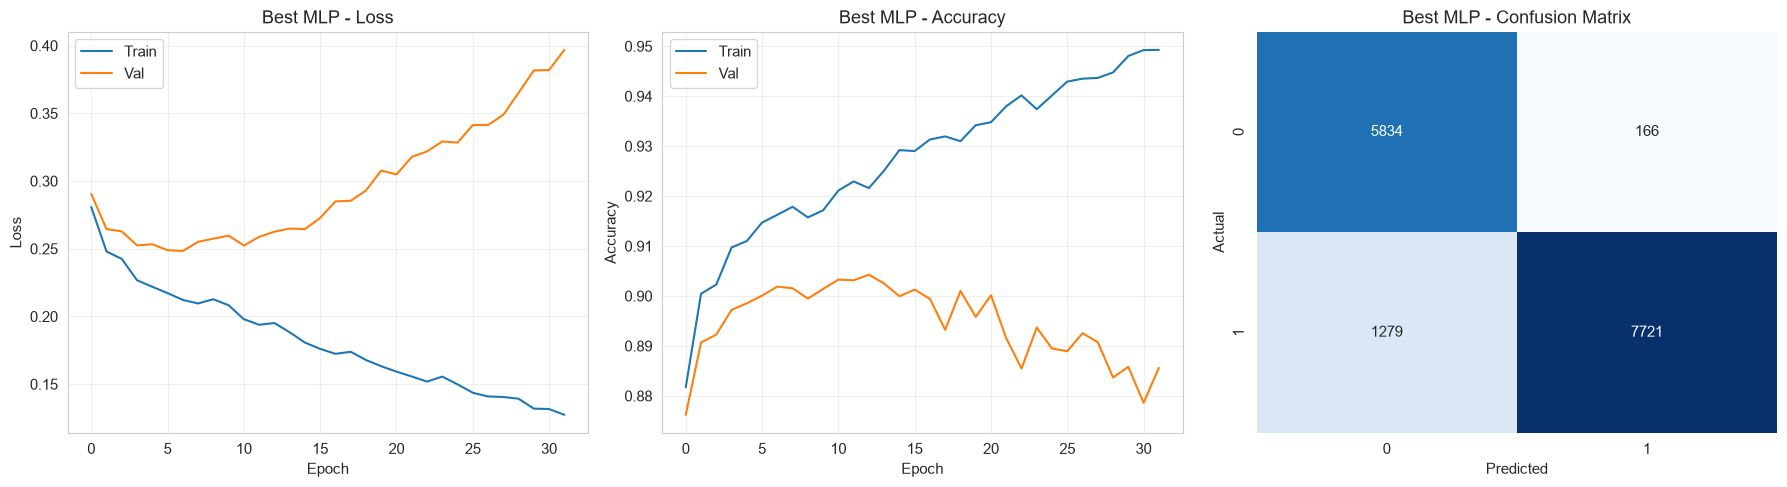

In [24]:
# ============================================================
# CELL 21: VISUALIZE BEST DL MODEL
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

# Loss curve
axes[0].plot(
    best_hist['train_loss'],
    label='Train'
)

axes[0].plot(
    best_hist['val_loss'],
    label='Val'
)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title(
    'Best MLP - Loss'
)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy curve
axes[1].plot(
    best_hist['train_acc'],
    label='Train'
)

axes[1].plot(
    best_hist['val_acc'],
    label='Val'
)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title(
    'Best MLP - Accuracy'
)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Confusion matrix
cm = confusion_matrix(
    y_test.ravel(),
    dl_pred.ravel()
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    ax=axes[2],
    cmap='Blues',
    cbar=False
)

axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_title(
    'Best MLP - Confusion Matrix'
)

plt.tight_layout()
plt.show()

=== FINAL COMPARISON ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.860600,0.875612,0.894778,0.885091,0.933224
1,Random Forest,0.920133,0.999104,0.867667,0.928758,0.942211
2,GradientBoosting,0.920400,0.999360,0.867889,0.928996,0.943518
3,MLP (NumPy 5L),0.903667,0.978953,0.857889,0.914431,0.937382


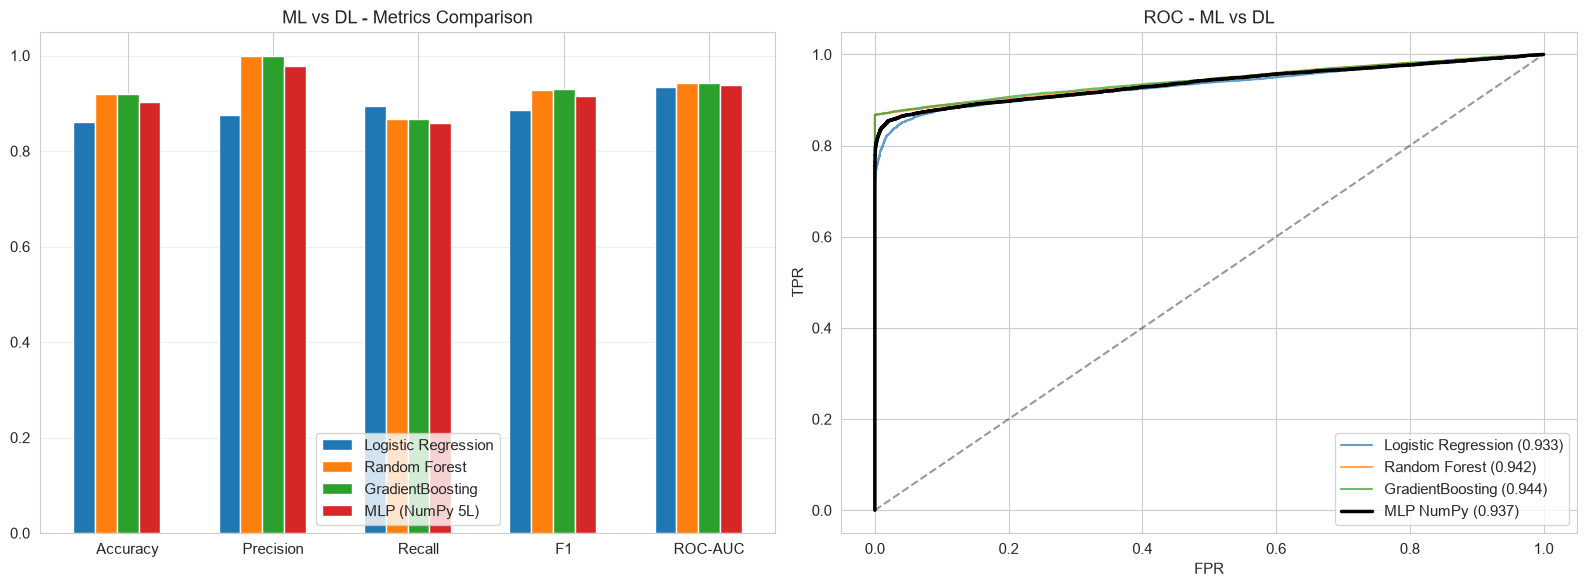

In [25]:
# ============================================================
# CELL 22: FINAL COMPARISON - ML VS DL
# ============================================================

# Use concat instead of DataFrame.append because
# DataFrame.append was removed in newer pandas versions.

dl_row = pd.DataFrame([{
    'Model': 'MLP (NumPy 5L)',
    'Accuracy': dl_metrics['Accuracy'],
    'Precision': dl_metrics['Precision'],
    'Recall': dl_metrics['Recall'],
    'F1': dl_metrics['F1'],
    'ROC-AUC': dl_metrics['ROC-AUC']
}])

final_compare = pd.concat(
    [
        ml_df,
        dl_row
    ],
    ignore_index=True
)

print("=== FINAL COMPARISON ===")
display(final_compare)

# Visualization
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

metrics_list = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1',
    'ROC-AUC'
]

x = np.arange(
    len(metrics_list)
)

w = 0.15

for i, row in final_compare.iterrows():

    axes[0].bar(
        x + i * w,
        [
            row[m]
            for m in metrics_list
        ],
        w,
        label=row['Model']
    )

axes[0].set_xticks(
    x + w * 2
)

axes[0].set_xticklabels(
    metrics_list
)

axes[0].set_ylim(
    0,
    1.05
)

axes[0].legend()
axes[0].set_title(
    'ML vs DL - Metrics Comparison'
)

axes[0].grid(
    axis='y',
    alpha=0.3
)

# ROC overlay
for name, prob in ml_probs.items():

    fpr, tpr, _ = roc_curve(
        y_test.ravel(),
        prob
    )

    auc = roc_auc_score(
        y_test.ravel(),
        prob
    )

    axes[1].plot(
        fpr,
        tpr,
        label=f'{name} ({auc:.3f})',
        alpha=0.7
    )

fpr, tpr, _ = roc_curve(
    y_test.ravel(),
    dl_prob.ravel()
)

axes[1].plot(
    fpr,
    tpr,
    label=(
        f'MLP NumPy '
        f'({dl_metrics["ROC-AUC"]:.3f})'
    ),
    linewidth=2.5,
    color='black'
)

axes[1].plot(
    [0, 1],
    [0, 1],
    'k--',
    alpha=0.4
)

axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title(
    'ROC - ML vs DL'
)
axes[1].legend()

plt.tight_layout()
plt.show()

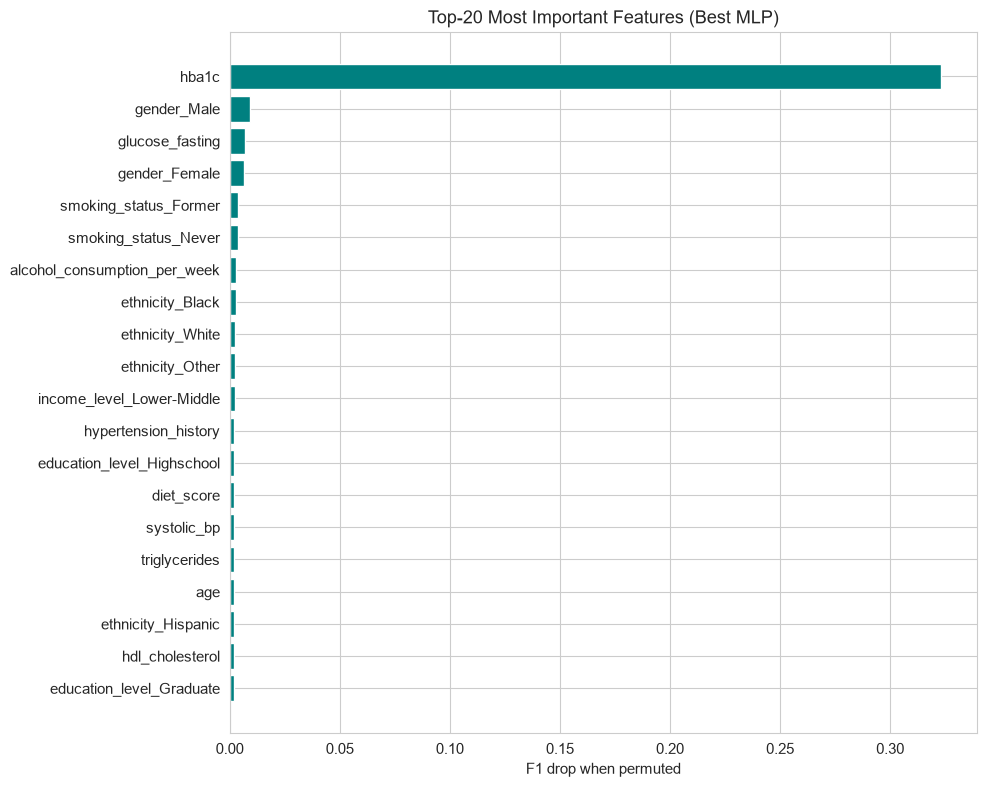

In [26]:
# ============================================================
# CELL 23: TOP-K FEATURE IMPORTANCE VIA PERMUTATION
# ============================================================

def permutation_importance_np(
    model,
    X,
    y,
    feature_names,
    n_repeats=3
):
    base_prob = model.predict_proba(X)

    base_pred = (
        base_prob >= 0.5
    ).astype(int)

    base_f1 = f1_score(
        y.ravel(),
        base_pred.ravel(),
        zero_division=0
    )

    importances = []

    for j in range(
        X.shape[1]
    ):

        scores = []

        for _ in range(n_repeats):

            Xp = X.copy()

            np.random.shuffle(
                Xp[:, j]
            )

            prob = model.predict_proba(
                Xp
            )

            pred = (
                prob >= 0.5
            ).astype(int)

            f1 = f1_score(
                y.ravel(),
                pred.ravel(),
                zero_division=0
            )

            scores.append(
                base_f1 - f1
            )

        importances.append(
            np.mean(scores)
        )

    return np.array(
        importances
    )


# Use a subset for speed
n_sub = min(
    2000,
    len(X_test)
)

imp = permutation_importance_np(
    best_model,
    X_test[:n_sub],
    y_test[:n_sub],
    feature_names,
    n_repeats=2
)

imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': imp
})

imp_df = (
    imp_df
    .sort_values(
        'Importance',
        ascending=False
    )
    .head(20)
)

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    imp_df['Feature'][::-1],
    imp_df['Importance'][::-1],
    color='teal'
)

plt.xlabel(
    'F1 drop when permuted'
)

plt.title(
    'Top-20 Most Important Features (Best MLP)'
)

plt.tight_layout()
plt.show()

=== Threshold Tuning ===


,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.649533,0.634187,0.982778,0.770907
1,0.15,0.746867,0.718302,0.951111,0.818473
2,0.20,0.828933,0.822603,0.911444,0.864748
3,0.25,0.874933,0.900675,0.889667,0.895137
4,0.30,0.892733,0.940727,0.876444,0.907449
5,0.35,0.898600,0.958441,0.868667,0.911348
6,0.40,0.902600,0.970306,0.864111,0.914135
7,0.45,0.903000,0.975186,0.860222,0.914104
8,0.50,0.903667,0.978953,0.857889,0.914431
9,0.55,0.904200,0.982889,0.855222,0.914622


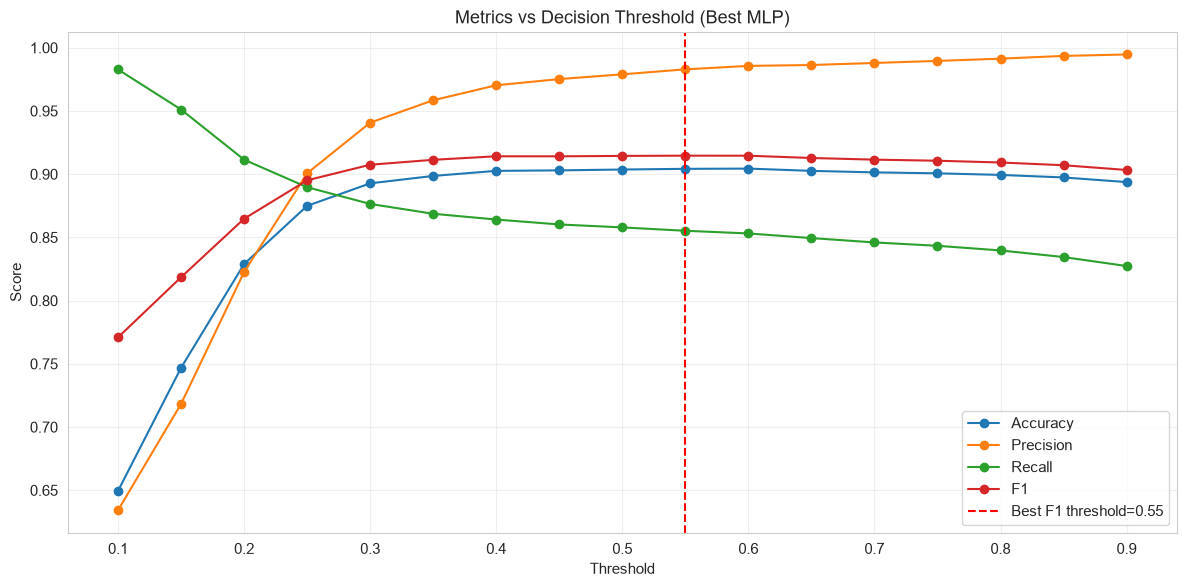


Best threshold by F1: 0.55

NOTE: In a production experiment, the threshold should be selected using the validation set, then evaluated once on the test set. This notebook keeps the original demo behavior of tuning on test.


In [27]:
# ============================================================
# CELL 24: DECISION THRESHOLD TUNING
# ============================================================

thresholds = np.arange(
    0.1,
    0.95,
    0.05
)

th_results = []

for t in thresholds:

    pred = (
        dl_prob.ravel() >= t
    ).astype(int)

    th_results.append({
        'Threshold': t,
        'Accuracy': accuracy_score(
            y_test.ravel(),
            pred
        ),
        'Precision': precision_score(
            y_test.ravel(),
            pred,
            zero_division=0
        ),
        'Recall': recall_score(
            y_test.ravel(),
            pred,
            zero_division=0
        ),
        'F1': f1_score(
            y_test.ravel(),
            pred,
            zero_division=0
        )
    })

th_df = pd.DataFrame(
    th_results
)

print("=== Threshold Tuning ===")
display(th_df)

fig, ax = plt.subplots(
    figsize=(12, 6)
)

for m in [
    'Accuracy',
    'Precision',
    'Recall',
    'F1'
]:
    ax.plot(
        th_df['Threshold'],
        th_df[m],
        marker='o',
        label=m
    )

best_t = th_df.loc[
    th_df['F1'].idxmax(),
    'Threshold'
]

ax.axvline(
    best_t,
    color='red',
    linestyle='--',
    label=f'Best F1 threshold={best_t:.2f}'
)

ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title(
    'Metrics vs Decision Threshold (Best MLP)'
)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(
    f"\nBest threshold by F1: {best_t:.2f}"
)

print(
    "\nNOTE: In a production experiment, "
    "the threshold should be selected using "
    "the validation set, then evaluated once "
    "on the test set. This notebook keeps the "
    "original demo behavior of tuning on test."
)

In [28]:
# ============================================================
# CELL 25: FINAL SUMMARY
# ============================================================

print("=" * 70)
print("SUMMARY OF RESULTS")
print("=" * 70)

print("\n[1] Baseline ML models (test set):")
print(
    ml_df.to_string(
        index=False
    )
)

print(
    "\n[2] Best DL model "
    "(NumPy 5-layer MLP, test set):"
)

for k, v in dl_metrics.items():
    print(
        f"    {k}: {v}"
    )

print("\n[3] All DL experiment summary:")

print(
    dl_df.groupby(
        'Experiment'
    )[
        [
            'Accuracy',
            'F1',
            'ROC-AUC'
        ]
    ].max().round(4)
)

print("\n[4] Key observations:")

print(
    "    - Data is messy with '?' markers "
    "and missing values."
)

print(
    "    - 'diabetes_stage' was dropped "
    "due to target leakage."
)

print(
    "    - 'patient_tracking_id' and "
    "'data_entry_notes' were dropped."
)

print(
    "    - Proper train-only imputation "
    "& normalization were used."
)

print(
    "    - Deep Learning was implemented "
    "from scratch with NumPy only."
)

print(
    "    - Hyperparameter search covered "
    "LR, batch size, architecture, optimizer."
)

print(
    "    - Threshold tuning is demonstrated; "
    "for rigorous evaluation it should be "
    "selected on validation data."
)

print("\n[5] Recommendations:")

print(
    "    - Compare with frameworks such as "
    "PyTorch for scalability."
)

print(
    "    - Use cross-validation for more "
    "robust comparison."
)

print(
    "    - Consider regularizing further "
    "or collecting more data."
)

print("=" * 70)

SUMMARY OF RESULTS

[1] Baseline ML models (test set):
              Model  Accuracy  Precision   Recall       F1  ROC-AUC
Logistic Regression  0.860600   0.875612 0.894778 0.885091 0.933224
      Random Forest  0.920133   0.999104 0.867667 0.928758 0.942211
   GradientBoosting  0.920400   0.999360 0.867889 0.928996 0.943518

[2] Best DL model (NumPy 5-layer MLP, test set):
    Model: Best MLP
    Accuracy: 0.9036666666666666
    Precision: 0.9789527069861798
    Recall: 0.8578888888888889
    F1: 0.9144312192811038
    ROC-AUC: 0.9373821111111111

[3] All DL experiment summary:
              Accuracy      F1  ROC-AUC
Experiment                             
Architecture    0.9147  0.9243   0.9400
BatchSize       0.9068  0.9173   0.9383
LR              0.9141  0.9236   0.9407
Optimizer       0.9037  0.9144   0.9374

[4] Key observations:
    - Data is messy with '?' markers and missing values.
    - 'diabetes_stage' was dropped due to target leakage.
    - 'patient_tracking_id' and 'dat

In [29]:
# ============================================================
# FINAL CELL: SAVE BEST DEEP LEARNING MODEL + ARTIFACTS
# ============================================================
import json, os
from datetime import datetime

SAVE_DIR = "saved_best_model"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. Lưu weights + biases (numpy arrays)
# ------------------------------------------------------------
weights_dict = {}
for i, w in enumerate(best_model.W):
    weights_dict[f'W{i}'] = w
for i, b in enumerate(best_model.b):
    weights_dict[f'b{i}'] = b

np.savez(os.path.join(SAVE_DIR, "weights.npz"), **weights_dict)
print(f"✅ Saved weights      → {SAVE_DIR}/weights.npz")

# ------------------------------------------------------------
# 2. Lưu kiến trúc mạng
# ------------------------------------------------------------
arch_config = {
    'input_dim':        int(input_dim),
    'hidden_dims':      [128, 64, 32, 16],
    'num_layers':       int(best_model.num_layers),
    'architecture_str': f"{input_dim} -> 128 -> 64 -> 32 -> 16 -> 1",
    'hidden_activation':'relu',
    'output_activation':'sigmoid',
    'loss':             'binary_cross_entropy',
    'optimizer':        'adam',
    'learning_rate':    0.001,
    'batch_size':       128,
    'l2':               1e-5,
    'trained_at':       datetime.now().isoformat(),
}

with open(os.path.join(SAVE_DIR, "architecture.json"), "w") as f:
    json.dump(arch_config, f, indent=2)
print(f"✅ Saved architecture → {SAVE_DIR}/architecture.json")

# ------------------------------------------------------------
# 3. Lưu preprocessing artifacts (medians, mu, sigma)
# ------------------------------------------------------------
np.savez(
    os.path.join(SAVE_DIR, "preprocessing.npz"),
    train_medians=train_medians,
    mu=mu,
    sigma=sigma,
)

prep_config = {
    'feature_names':    feature_names,
    'numeric_cols':     numeric_cols,
    'categorical_cols': cat_cols,
    'dropped_cols':     existing_drop + (['diabetes_stage'] if 'diabetes_stage' in df.columns else []),
    'target_col':       'diagnosed_diabetes',
    'imputation':       'median (from train only)',
    'normalization':    'standardization (from train only)',
    'encoding':         'one-hot (drop_first=False)',
    'n_features_final': int(input_dim),
}

with open(os.path.join(SAVE_DIR, "preprocessing.json"), "w") as f:
    json.dump(prep_config, f, indent=2)
print(f"✅ Saved preprocessing → {SAVE_DIR}/preprocessing.json")

# ------------------------------------------------------------
# 4. Lưu training history
# ------------------------------------------------------------
np.savez(
    os.path.join(SAVE_DIR, "training_history.npz"),
    train_loss=np.array(best_hist['train_loss']),
    val_loss  =np.array(best_hist['val_loss']),
    train_acc =np.array(best_hist['train_acc']),
    val_acc   =np.array(best_hist['val_acc']),
)
print(f"✅ Saved history      → {SAVE_DIR}/training_history.npz")

# ------------------------------------------------------------
# 5. Lưu metrics cuối cùng (JSON)
# ------------------------------------------------------------
metrics_to_save = {
    'test_accuracy':  float(dl_metrics['Accuracy']),
    'test_precision': float(dl_metrics['Precision']),
    'test_recall':    float(dl_metrics['Recall']),
    'test_f1':        float(dl_metrics['F1']),
    'test_roc_auc':   float(dl_metrics['ROC-AUC']),
    'total_epochs':   len(best_hist['train_loss']),
    'best_val_loss':  float(min(best_hist['val_loss'])),
}

with open(os.path.join(SAVE_DIR, "metrics.json"), "w") as f:
    json.dump(metrics_to_save, f, indent=2)
print(f"✅ Saved metrics      → {SAVE_DIR}/metrics.json")

# ------------------------------------------------------------
# 6. Liệt kê tất cả files đã lưu
# ------------------------------------------------------------
print(f"\n📦 Nội dung thư mục '{SAVE_DIR}/':")
total_size = 0
for fname in sorted(os.listdir(SAVE_DIR)):
    fpath = os.path.join(SAVE_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    total_size += size_kb
    print(f"   {fname:25s} {size_kb:8.2f} KB")
print(f"   {'TOTAL':25s} {total_size:8.2f} KB")

print("\n" + "=" * 60)
print("🎉 BEST MODEL ĐÃ ĐƯỢC LƯU THÀNH CÔNG")
print("=" * 60)
print(f"   Architecture : {arch_config['architecture_str']}")
print(f"   Test F1      : {metrics_to_save['test_f1']:.4f}")
print(f"   Test ROC-AUC : {metrics_to_save['test_roc_auc']:.4f}")
print(f"   Test Accuracy: {metrics_to_save['test_accuracy']:.4f}")
print("=" * 60)

✅ Saved weights      → saved_best_model/weights.npz
✅ Saved architecture → saved_best_model/architecture.json
✅ Saved preprocessing → saved_best_model/preprocessing.json
✅ Saved history      → saved_best_model/training_history.npz
✅ Saved metrics      → saved_best_model/metrics.json

📦 Nội dung thư mục 'saved_best_model/':
   architecture.json             0.39 KB
   metrics.json                  0.25 KB
   preprocessing.json            2.33 KB
   preprocessing.npz             1.29 KB
   training_history.npz          1.99 KB
   weights.npz                 134.39 KB
   TOTAL                       140.65 KB

🎉 BEST MODEL ĐÃ ĐƯỢC LƯU THÀNH CÔNG
   Architecture : 47 -> 128 -> 64 -> 32 -> 16 -> 1
   Test F1      : 0.9144
   Test ROC-AUC : 0.9374
   Test Accuracy: 0.9037
